# Modality-Invariant Representation Learning for Fair Skin Disease Classification (Version 1)


## Dataset Split

| Role | Dataset | Modality |
|------|---------|----------|
| **Train (paired)** | HIBA | Clinical + Dermoscopic |
| **Train (unpaired clinical)** | Fitzpatrick17k | Clinical |
| **Train (unpaired derm)** | HAM10000 | Dermoscopic |
| **Eval** | Dermnet | Various |

## Unified 7-Class Taxonomy

| ID | Class |
|----|-------|
| 0 | Melanoma |
| 1 | Melanocytic Nevus |
| 2 | Basal Cell Carcinoma |
| 3 | Actinic Keratosis |
| 4 | Seborrheic Keratosis |
| 5 | Squamous Cell Carcinoma |
| 6 | Other |

## Notebook Roadmap

| Phase | Section |
|-------|---------|
| 0 | Environment setup, Drive mount |
| 1 | Data parsers, label harmonization, CSV building, loaders |
| 2 | Dual-encoder ViT architecture |
| 3 | Multi-objective loss functions |
| 4 | Training loop with Drive checkpointing |
| 5 | Fairness evaluation (EOM, PQD, DPM, FATE) |
| 6 | Ablation studies |
| 7 | Visualization (curves, FST bars, cross-dataset, UMAP) |
| 8 | SHAP explainability (GradientSHAP, GradCAM, fairness-SHAP) |

**Runtime:** T4 GPU or better. Full training ~8–12 h.

## Phase 0 — Environment Setup

In [30]:
!pip install -q timm einops scikit-learn umap-learn \
               matplotlib seaborn pandas tqdm Pillow \
               shap captum

In [31]:
import os, re, glob, random, math, json, warnings, shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

import shap
from captum.attr import (GradientShap, IntegratedGradients,
                         NoiseTunnel, LayerGradCam, LayerAttribution)
from captum.attr import visualization as viz

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [32]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIG
# ════════════════════════════════════════════════════════════════════════════
# /kaggle/input  is READ-ONLY  — dataset sources live here
# /kaggle/working is WRITABLE  — all generated outputs go here

DRIVE_ROOT = Path('/kaggle/input/datasets')   # read-only data sources
WORK_ROOT  = Path('/kaggle/working')           # writable output root

CFG = dict(
    # Dataset roots  (read-only)
    hiba_root     = DRIVE_ROOT / 'asosenge/hibaskinlesionsdataset-main',
    fitz_root     = DRIVE_ROOT / 'asosenge/fitzpatrick17k',
    ham_root      = DRIVE_ROOT / 'asosenge/ham10000',
    dermnet_root  = DRIVE_ROOT / 'shubhamgoel27/dermnet',
    # Outputs  (writable)
    csv_dir       = WORK_ROOT / 'csvs',
    ckpt_dir      = WORK_ROOT / 'checkpoints',
    results_dir   = WORK_ROOT / 'results',
    shap_dir      = WORK_ROOT / 'results/shap',
    # Architecture
    backbone      = 'vit_small_patch16_224',
    embed_dim     = 512,
    img_size      = 224,
    # Training
    batch_size    = 32,
    num_epochs    = 1,
    lr            = 1e-4,
    weight_decay  = 1e-4,
    warmup_epochs = 1,
    # Loss weights
    lambda_cls    = 1.0,
    lambda_conf   = 0.5,
    lambda_con    = 0.5,
    lambda_mi     = 1.0,
    temperature   = 0.07,
    # Labels
    num_classes    = 7,
    num_skin_types = 6,
    # Ablation flags
    use_conf = True, use_con = True, use_mi = True,
)

LABEL_NAMES = {
    0:'Melanoma', 1:'Melanocytic Nevus', 2:'Basal Cell Carcinoma',
    3:'Actinic Keratosis', 4:'Seborrheic Keratosis',
    5:'Squamous Cell Carcinoma', 6:'Other',
}
FST_NAMES = {i: f'FST {i+1}' for i in range(6)}

for k in ['csv_dir','ckpt_dir','results_dir','shap_dir']:
    CFG[k].mkdir(parents=True, exist_ok=True)

print('Config ready. Checking dataset roots:')
for k in ['hiba_root','fitz_root','ham_root','dermnet_root']:
    status = 'OK' if CFG[k].exists() else 'MISSING — update path'
    print(f'  [{status}]  {k}')


Config ready. Checking dataset roots:
  [OK]  hiba_root
  [OK]  fitz_root
  [OK]  ham_root
  [OK]  dermnet_root


## Phase 1 — Data Preparation

### 1-A  Label Taxonomy & Mapping Tables

In [33]:
# ════════════════════════════════════════════════════════════════════════════
# LABEL MAPPING TABLES  (raw string → canonical int 0-6)
# ════════════════════════════════════════════════════════════════════════════
HAM_MAP = {'mel':0,'nv':1,'bcc':2,'akiec':3,'bkl':4,'df':6,'vasc':6}

HIBA_MAP = {
    'melanoma':0,'nevo melanocitico':1,'nevo':1,'carcinoma basocelular':2,
    'queratosis seborreica':4,'queratosis actinica':3,
    'carcinoma espinocelular':5,'dermatofibroma':6,'lesion vascular':6,'otros':6,
}

FITZ_MAP = {
    'squamous cell carcinoma':5,'basal cell carcinoma':2,'melanoma':0,
    'actinic keratosis':3,'seborrheic keratosis':4,'melanocytic nevus':1,
    'pigmented benign keratosis':4,'dermatofibroma':6,'vascular lesion':6,
}
DERMNET_MAP = {
    'melanoma skin cancer nevi and moles':0,
    'actinic keratosis basal cell carcinoma and other malignant lesions':2,
    'seborrheic keratoses and other benign tumors':4,
}

def harmonize_label(raw, mapping, default=6):
    s = str(raw).lower().strip()
    if s in mapping: return mapping[s]
    for k, v in mapping.items():
        if k in s or s in k: return v
    return default

def parse_fst(raw):
    try:
        v = int(float(str(raw))) - 1
        return v if 0 <= v <= 5 else -1
    except (ValueError, TypeError):
        return -1

print('Label taxonomy ready — 7 canonical classes.')

Label taxonomy ready — 7 canonical classes.


### 1-B  Dataset Parsers

In [34]:
# ════════════════════════════════════════════════════════════════════════════
# PAIRED PARSERS  (Derm7pt  &  HIBA)
# ════════════════════════════════════════════════════════════════════════════

def _safe_split(df, test_size=0.15, seed=42):
    """Stratified split.  Classes with only 1 sample are kept in train only
    (stratify would fail; a singleton class can't appear in both splits)."""
    if df.empty: return df, df
    # Count samples per class; singletons can't be stratified
    cts      = df['label'].value_counts()
    rare     = cts[cts < 2].index
    df_rare  = df[df['label'].isin(rare)]
    df_rest  = df[~df['label'].isin(rare)]
    if df_rest.empty:
        return df, df.iloc[:0]          # all rare — put everything in train
    try:
        tr, va = train_test_split(df_rest, test_size=test_size,
                                  random_state=seed, stratify=df_rest['label'])
    except ValueError:
        tr, va = train_test_split(df_rest, test_size=test_size, random_state=seed)
    # Rare-class samples go to train only (they can't contribute to val AUROC anyway)
    tr = pd.concat([tr, df_rare], ignore_index=True)
    return tr, va


def parse_hiba(root: Path):
    candidates = (list(root.rglob('metadata.csv')) +
                  list(root.rglob('hiba_metadata.csv')) +
                  list(root.rglob('hospital-italiano-de-buenos-aires-skin-lesions-images-2019-2022.csv')))
    # Add a print to confirm if metadata CSV is found
    if not candidates:
        print(f'[WARN] HIBA: metadata CSV not found under {root}'); return pd.DataFrame(), pd.DataFrame()
    else:
        print(f'[DEBUG HIBA] Found metadata CSV: {candidates[0]}')

    meta    = pd.read_csv(candidates[0])

    # Determine the primary ID column for grouping lesions
    lesion_id_col = next((c for c in ['lesion_id','case_id','id']
                          if c in meta.columns), None)
    if not lesion_id_col:
        print('[WARN] HIBA: Could not find a suitable lesion ID column (lesion_id, case_id, id).'); return pd.DataFrame(), pd.DataFrame()
    else:
        print(f'[DEBUG HIBA] Using lesion ID column: {lesion_id_col}')

    # Ensure necessary columns for image type and filename are present
    if 'image_type' not in meta.columns or 'isic_id' not in meta.columns:
        print('[WARN] HIBA: "image_type" or "isic_id" column missing in metadata.csv'); return pd.DataFrame(), pd.DataFrame()
    else:
        print(f'[DEBUG HIBA] image_type and isic_id columns found.')

    # NEW: Build a map of all image files once for the root directory
    print(f'[DEBUG HIBA] Building image path map for {root}...')
    image_path_map = _build_image_map(root)
    print(f'[DEBUG HIBA] Image map built with {len(image_path_map)} entries.')

    # Group by the main lesion ID column to find paired images
    lesion_groups = meta.groupby(lesion_id_col)

    rows = []
    num_images_processed = 0
    num_clinical_found = 0
    num_derm_found = 0
    num_pairs_found = 0

    for lesion_id_val, group in lesion_groups:
        clinical_img_path = None
        derm_img_path     = None
        diagnosis_for_lesion = None

        for _, r in group.iterrows():
            num_images_processed += 1
            img_id_for_filename = str(r['isic_id'])
            img_type   = str(r['image_type']).lower()
            diag       = str(r.get('diagnosis', r.get('dx','otros')))

            if diagnosis_for_lesion is None: # Capture diagnosis once for the lesion
                diagnosis_for_lesion = diag

            # Replace _find_image call with map lookup
            current_img_path = image_path_map.get(img_id_for_filename)
            if not current_img_path:
                # Also try looking up by stem if the meta ID is a full filename
                if '.' in img_id_for_filename:
                    current_img_path = image_path_map.get(Path(img_id_for_filename).stem)

            if not current_img_path:
                # print(f'[DEBUG HIBA] Image not found in map for ISIC ID: {img_id_for_filename}')
                pass # Suppress this for now to reduce output unless critical

            if current_img_path:
                if 'clinical' in img_type or 'overview' in img_type:
                    clinical_img_path = current_img_path
                    num_clinical_found += 1
                elif 'dermoscopic' in img_type or 'derm' in img_type:
                    derm_img_path = current_img_path
                    num_derm_found += 1

        # If both clinical and dermoscopic images are found for this lesion, add to rows
        if clinical_img_path and derm_img_path:
            rows.append({
                'lesion_id': f'hiba_{lesion_id_val}',
                'clinical_path': str(clinical_img_path),
                'derm_path': str(derm_img_path),
                'label': harmonize_label(diagnosis_for_lesion, HIBA_MAP),
                'skin_type': -1,
                'dataset': 'hiba'
            })
            num_pairs_found += 1

    df = pd.DataFrame(rows)
    tr, va = _safe_split(df)
    print(f'[DEBUG HIBA] Total images processed: {num_images_processed}')
    print(f'[DEBUG HIBA] Clinical images found: {num_clinical_found}')
    print(f'[DEBUG HIBA] Dermoscopic images found: {num_derm_found}')
    print(f'[DEBUG HIBA] Paired lesions found: {num_pairs_found}')
    print(f'HIBA      — {len(tr):>4} train  {len(va):>4} val  pairs')
    return tr, va

print('Paired parsers ready.')

Paired parsers ready.


In [35]:
# ════════════════════════════════════════════════════════════════════════════
# UNPAIRED CLINICAL PARSERS  (Fitzpatrick17k | PAD-UFES-20 | DDI)
# ════════════════════════════════════════════════════════════════════════════

def _find_image(img_id, search_dirs, exts=['.jpg','.jpeg','.png'], recursive=False):
    for d in search_dirs:
        for e in exts:
            if recursive:
                # Use rglob for recursive search
                candidates = list(d.rglob(f'{img_id}{e}'))
                if candidates:
                    return candidates[0]
            else:
                # Non-recursive search, directly in the specified directory
                p = d / f'{img_id}{e}'
                if p.exists(): return p
    return None

def _build_image_map(root_dir: Path, exts=['.jpg','.jpeg','.png']):
    """Recursively builds a map from image filename (stem and full name) to its full path."""
    image_map = {}
    for ext in exts:
        for p in root_dir.rglob(f'*{ext}'):
            image_map[p.stem] = p
            image_map[p.name] = p # Also store with full filename in case metadata provides that
    return image_map

def parse_fitzpatrick17k(root: Path):
    csvs = list(root.glob('fitzpatrick17k.csv'))
    if not csvs: print(f'[WARN] Fitzpatrick17k CSV missing'); return pd.DataFrame(), pd.DataFrame()
    meta    = pd.read_csv(csvs[0])
    img_dir = root/'data/finalfitz17k' if (root/'data/finalfitz17k').exists() else root

    print(f'[DEBUG FITZ] Building image path map for {img_dir}...')
    image_path_map = _build_image_map(img_dir)
    print(f'[DEBUG FITZ] Image map built with {len(image_path_map)} entries.')

    rows = []
    for _, r in meta.iterrows():
        fst = parse_fst(r.get('fitzpatrick', r.get('fitzpatrick_scale',-1)))
        p   = None
        for col in ['md5hash','image_id','file_name']:
            if col in r.index and pd.notna(r[col]):
                candidate_id = str(r[col])
                p = image_path_map.get(candidate_id)
                if p: break
                # If meta ID is full filename, try lookup by stem
                if '.' in candidate_id:
                    p = image_path_map.get(Path(candidate_id).stem)
                    if p: break
        if p is None and 'url' in r.index:
            base = str(r['url']).split('/')[-1].split('?')[0]
            p = image_path_map.get(base)
            if p is None and '.' in base:
                p = image_path_map.get(Path(base).stem)
        if p is None: continue
        raw = str(r.get('nine_partition_label', r.get('label','other'))).lower()
        rows.append({'image_path':str(p),'label':harmonize_label(raw,FITZ_MAP),
                     'skin_type':fst,'dataset':'fitzpatrick17k'})
    df = pd.DataFrame(rows)
    tr, va = _safe_split(df)
    fst_known_count = 0
    if not df.empty and 'skin_type' in df.columns:
        fst_known_count = (df.skin_type>=0).sum()
    print(f'Fitzpatrick17k — {len(tr):>6} train  {len(va):>5} val  | FST known: {fst_known_count}')
    return tr, va


print('Clinical parsers ready.')

Clinical parsers ready.


In [36]:
# ════════════════════════════════════════════════════════════════════════════
# UNPAIRED DERM PARSERS  (HAM10000 | ISIC 2018)
# ════════════════════════════════════════════════════════════════════════════

def parse_ham10000(root: Path):
    # rglob searches recursively — finds the CSV wherever it lives under root
    csvs = list(root.rglob('HAM10000_metadata.csv'))
    if not csvs:
        print('[WARN] HAM10000 CSV missing'); return pd.DataFrame(), pd.DataFrame()
    
    meta_path = csvs[0]
    meta_root = meta_path.parent          # e.g. .../ham10000/HAM10000/
    print(f'[DEBUG HAM] Found metadata at: {meta_path}')
    meta = pd.read_csv(meta_path)

    # Search for images relative to where the CSV lives, plus common subfolder patterns
    img_dirs = (
        [meta_root/'images'] +
        [meta_root/f'HAM10000_images_part_{i}' for i in [1, 2]] +
        [meta_root/f'images_part_{i}'          for i in [1, 2]] +
        [meta_root]                             # fallback: same folder as CSV
    )

    print(f'[DEBUG HAM] Building image path map...')
    image_path_map = _build_image_map(meta_root)
    print(f'[DEBUG HAM] Image map built with {len(image_path_map)} entries.')

    rows = []
    for _, r in meta.iterrows():
        img_id = str(r.get('image_id', ''))
        dx     = str(r.get('dx', 'other')).lower().strip()
        # Try the map first (fast), fall back to directory search
        p = image_path_map.get(img_id) or _find_image(img_id, img_dirs)
        if p:
            rows.append({'image_path': str(p), 'label': HAM_MAP.get(dx, 6),
                         'skin_type': -1, 'dataset': 'ham10000'})

    df = pd.DataFrame(rows)
    tr, va = _safe_split(df)
    print(f'HAM10000       — {len(tr):>6} train  {len(va):>5} val')
    return tr, va

print('Dermoscopic parsers ready.')

Dermoscopic parsers ready.


In [37]:
# ════════════════════════════════════════════════════════════════════════════
# EVALUATION DATASET PARSERS  (Dermnet | generic folder)
# ════════════════════════════════════════════════════════════════════════════

def parse_folder_dataset(root: Path, label_map: dict, ds_name: str):
    rows = []
    for folder in sorted(root.rglob('*')):
        if not folder.is_dir(): continue
        label = harmonize_label(folder.name.lower(), label_map)
        for f in folder.iterdir():
            if f.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                rows.append({'image_path': str(f), 'label': label,
                             'skin_type': -1, 'dataset': ds_name})
    df = pd.DataFrame(rows)
    print(f'{ds_name:<18} (eval) — {len(df):>6} images')
    return df

def parse_dermnet(root):
    return parse_folder_dataset(root, DERMNET_MAP, 'dermnet')


# ── ITA-based Fitzpatrick Skin Type estimator ─────────────────────────────

# ITA → FST mapping  (Chardon 1991 / Del Bino 2006)
_ITA_BRACKETS = [
    ( 55.0,  float('inf'), 0),   # FST I
    ( 28.0,  55.0,         1),   # FST II
    ( 10.0,  28.0,         2),   # FST III
    (-30.0,  10.0,         3),   # FST IV
    (-55.0, -30.0,         4),   # FST V
    (float('-inf'), -55.0, 5),   # FST VI
]

def _ita_to_fst(ita: float) -> int:
    for lo, hi, fst in _ITA_BRACKETS:
        if lo < ita <= hi:
            return fst
    return _ITA_BRACKETS[-1][2]   # FST VI for very low ITA

def _estimate_fst_single(path: str,
                          min_skin_frac: float = 0.05,
                          thumb_size: int = 96) -> int:
    """Estimate Fitzpatrick Skin Type from a single image file.

    Algorithm:
    1. Resize to thumb_size×thumb_size (fast, keeps colour statistics).
    2. Convert RGB → CIE L*a*b* (skimage).
    3. Select skin pixels: L* ∈ (20, 90), a* > 2, b* > 5.
    4. If skin fraction < min_skin_frac → return -1 (insufficient skin area).
    5. Compute ITA = arctan((mean_L - 50) / mean_b) × 180/π.
    6. Map ITA → FST I–VI (0–5).

    Returns -1 if the image cannot be read or has too little skin area.
    """
    try:
        from skimage import color as _skcolor
        img = Image.open(path).convert('RGB')
        img = img.resize((thumb_size, thumb_size), Image.BILINEAR)
        rgb = np.asarray(img, dtype=np.float32) / 255.0   # (H, W, 3) ∈ [0,1]
        lab = _skcolor.rgb2lab(rgb)                         # (H, W, 3)
        L, a, b = lab[..., 0], lab[..., 1], lab[..., 2]

        skin_mask = (L > 20) & (L < 90) & (a > 2) & (b > 5)
        frac = skin_mask.mean()
        if frac < min_skin_frac:
            return -1

        mean_L = float(L[skin_mask].mean())
        mean_b = float(b[skin_mask].mean())
        if abs(mean_b) < 1e-6:
            return -1

        ita = float(np.degrees(np.arctan((mean_L - 50.0) / mean_b)))
        return _ita_to_fst(ita)
    except Exception:
        return -1


def estimate_fst_for_csv(df: pd.DataFrame,
                          n_jobs: int = 4,
                          cache_csv: Path = None) -> pd.DataFrame:
    """Add / overwrite the 'skin_type' column in df using ITA estimation.

    Parameters
    ----------
    df        : DataFrame with at least an 'image_path' column.
    n_jobs    : Number of parallel worker threads (I/O bound → threads fine).
    cache_csv : If given and the file exists, load cached FST values instead
                of recomputing.  If the file does not exist, compute and save.

    Returns
    -------
    df with 'skin_type' column filled (−1 where estimation failed).
    """
    if cache_csv is not None and Path(cache_csv).exists():
        cached = pd.read_csv(cache_csv)
        if 'skin_type' in cached.columns and len(cached) == len(df):
            df = df.copy()
            df['skin_type'] = cached['skin_type'].values
            n_known = (df['skin_type'] >= 0).sum()
            print(f'  [FST cache] loaded {n_known}/{len(df)} annotated from {Path(cache_csv).name}')
            return df

    print(f'  Estimating FST via ITA for {len(df)} images  '
          f'(n_jobs={n_jobs}) …')

    from concurrent.futures import ThreadPoolExecutor
    paths = df['image_path'].tolist()

    with ThreadPoolExecutor(max_workers=n_jobs) as ex:
        fst_values = list(tqdm(
            ex.map(_estimate_fst_single, paths),
            total=len(paths), desc='  ITA-FST', leave=True))

    df = df.copy()
    df['skin_type'] = fst_values
    n_known = sum(v >= 0 for v in fst_values)
    print(f'  FST estimated: {n_known}/{len(df)} images '
          f'({100*n_known/max(len(df),1):.1f}%) with valid skin area')
    for fst_i in range(6):
        cnt = sum(v == fst_i for v in fst_values)
        if cnt:
            print(f'    FST {fst_i+1}: {cnt:>5} images')

    if cache_csv is not None:
        df.to_csv(cache_csv, index=False)
        print(f'  Saved FST cache → {Path(cache_csv).name}')

    return df


print('Evaluation parsers + ITA-FST estimator ready.')

Evaluation parsers + ITA-FST estimator ready.


### 1-C  Build CSVs & Data Loaders

In [38]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD ALL CSVs
# ════════════════════════════════════════════════════════════════════════════
print('='*60, '\nBuilding training CSVs ...')
hiba_tr, hiba_va = parse_hiba(CFG['hiba_root'])
fitz_tr, fitz_va = parse_fitzpatrick17k(CFG['fitz_root'])
ham_tr,  ham_va  = parse_ham10000(CFG['ham_root'])

paired_train = pd.concat([hiba_tr], ignore_index=True)
paired_val   = pd.concat([hiba_va], ignore_index=True)
clin_train   = pd.concat([fitz_tr], ignore_index=True)
clin_val     = pd.concat([fitz_va], ignore_index=True)
derm_train   = pd.concat([ham_tr],  ignore_index=True)
derm_val     = pd.concat([ham_va],  ignore_index=True)

print('\nBuilding evaluation CSVs ...')
dermnet_eval = parse_dermnet(CFG['dermnet_root'])

# ── ITA-based FST estimation for Dermnet ─────────────────────────────────
# Dermnet has no metadata FST labels, so we estimate skin type directly
# from each image using the Individual Typology Angle (ITA) in L*a*b* space.
# Results are cached to eval_dermnet_fst_cache.csv so subsequent runs are
# instant (just load the cache instead of re-processing every image).
if not dermnet_eval.empty:
    _dermnet_cache = CFG['csv_dir'] / 'eval_dermnet_fst_cache.csv'
    dermnet_eval = estimate_fst_for_csv(
        dermnet_eval, n_jobs=4, cache_csv=_dermnet_cache)

save_map = {
    'paired_train.csv': paired_train, 'paired_val.csv': paired_val,
    'clin_train.csv'  : clin_train,   'clin_val.csv'  : clin_val,
    'derm_train.csv'  : derm_train,   'derm_val.csv'  : derm_val,
    'eval_dermnet.csv': dermnet_eval,
}
csv = CFG['csv_dir']
for fname, df in save_map.items():
    if not df.empty:
        df.to_csv(csv/fname, index=False)
        print(f'  Saved {fname:<25} ({len(df):>6} rows)')

print(f'\nTotal training samples: {len(paired_train)+len(clin_train)+len(derm_train):,}')

Building training CSVs ...
[DEBUG HIBA] Found metadata CSV: /kaggle/input/datasets/asosenge/hibaskinlesionsdataset-main/HIBASkinLesionsDataset-main/hospital-italiano-de-buenos-aires-skin-lesions-images-2019-2022.csv
[DEBUG HIBA] Using lesion ID column: lesion_id
[DEBUG HIBA] image_type and isic_id columns found.
[DEBUG HIBA] Building image path map for /kaggle/input/datasets/asosenge/hibaskinlesionsdataset-main...
[DEBUG HIBA] Image map built with 3232 entries.
[DEBUG HIBA] Total images processed: 1616
[DEBUG HIBA] Clinical images found: 346
[DEBUG HIBA] Dermoscopic images found: 1270
[DEBUG HIBA] Paired lesions found: 290
HIBA      —  246 train    44 val  pairs
[DEBUG FITZ] Building image path map for /kaggle/input/datasets/asosenge/fitzpatrick17k...
[DEBUG FITZ] Image map built with 33154 entries.
Fitzpatrick17k —  14090 train   2487 val  | FST known: 16012
[DEBUG HAM] Found metadata at: /kaggle/input/datasets/asosenge/ham10000/HAM10000/HAM10000_metadata.csv
[DEBUG HAM] Building imag

  ITA-FST:   0%|          | 0/19559 [00:00<?, ?it/s]

  FST estimated: 17156/19559 images (87.7%) with valid skin area
    FST 1:  1061 images
    FST 2:  4564 images
    FST 3:  3686 images
    FST 4:  5283 images
    FST 5:  1992 images
    FST 6:   570 images
  Saved FST cache → eval_dermnet_fst_cache.csv
  Saved paired_train.csv          (   246 rows)
  Saved paired_val.csv            (    44 rows)
  Saved clin_train.csv            ( 14090 rows)
  Saved clin_val.csv              (  2487 rows)
  Saved derm_train.csv            (  8512 rows)
  Saved derm_val.csv              (  1503 rows)
  Saved eval_dermnet.csv          ( 19559 rows)

Total training samples: 22,848


In [39]:
# ════════════════════════════════════════════════════════════════════════════
# TRANSFORMS  &  DATASET CLASSES
# ════════════════════════════════════════════════════════════════════════════
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((CFG['img_size']+32, CFG['img_size']+32)),
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.1, 0.05),
    transforms.RandomRotation(15),
    transforms.ToTensor(), transforms.Normalize(IMG_MEAN, IMG_STD),
])
val_tfm = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(), transforms.Normalize(IMG_MEAN, IMG_STD),
])
denorm_tfm = transforms.Compose([
    transforms.Normalize(mean=[0,0,0], std=[1/s for s in IMG_STD]),
    transforms.Normalize(mean=[-m for m in IMG_MEAN], std=[1,1,1]),
])


class UnpairedSkinDataset(Dataset):
    def __init__(self, df_or_csv, modality='clinical', transform=None):
        self.df = (pd.read_csv(df_or_csv) if isinstance(df_or_csv,(str,Path))
                   else df_or_csv.reset_index(drop=True))
        self.modality = modality; self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        try: img = Image.open(r['image_path']).convert('RGB')
        except: img = Image.new('RGB',(224,224))
        if self.transform: img = self.transform(img)
        return {'image':img,
                'label'    :torch.tensor(int(r['label']),    dtype=torch.long),
                'skin_type':torch.tensor(int(r['skin_type']),dtype=torch.long),
                'modality' :self.modality, 'paired':False,
                'image_path': str(r['image_path'])}


class PairedSkinDataset(Dataset):
    def __init__(self, df_or_csv, transform=None):
        self.df = (pd.read_csv(df_or_csv) if isinstance(df_or_csv,(str,Path))
                   else df_or_csv.reset_index(drop=True))
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        try:
            clin = Image.open(r['clinical_path']).convert('RGB')
            derm = Image.open(r['derm_path']).convert('RGB')
        except:
            clin = derm = Image.new('RGB',(224,224))
        if self.transform: clin=self.transform(clin); derm=self.transform(derm)
        return {'clinical':clin,'derm':derm,
                'label'    :torch.tensor(int(r['label']),    dtype=torch.long),
                'skin_type':torch.tensor(int(r['skin_type']),dtype=torch.long),
                'paired':True}


class MixedDataset(Dataset):
    def __init__(self, paired_ds, unpaired_list):
        self.paired   = paired_ds
        self.unpaired = unpaired_list
        self.index = (
            [('p',i)     for i in range(len(paired_ds))] +
            [('u',di,i)  for di,ds in enumerate(unpaired_list)
                         for i in range(len(ds))]
        )
    def __len__(self): return len(self.index)
    def __getitem__(self, i):
        e = self.index[i]
        return self.paired[e[1]] if e[0]=='p' else self.unpaired[e[1]][e[2]]


def mixed_collate(batch):
    """FIX: separate paired vs unpaired items, stack each pool independently,
    so that 'clinical'/'derm' tensors contain ONLY paired rows and
    'image' contains ONLY unpaired rows — matching the boolean masks in forward().
    """
    paired_items   = [item for item in batch if item.get('paired') is True]
    unpaired_items = [item for item in batch if item.get('paired') is not True]

    result = {}

    # Always include these for every sample
    all_labels    = [item['label']     for item in batch]
    all_skins     = [item['skin_type'] for item in batch]
    all_paired    = [item['paired']    for item in batch]
    all_modality  = [item.get('modality', 'clinical') for item in batch]
    all_imgpath   = [item.get('image_path', '') for item in batch]

    result['label']      = torch.stack(all_labels)
    result['skin_type']  = torch.stack(all_skins)
    result['paired']     = all_paired
    result['modality']   = all_modality
    result['image_path'] = all_imgpath

    # Stack paired images (only rows that are paired)
    if paired_items:
        result['clinical'] = torch.stack([item['clinical'] for item in paired_items])
        result['derm']     = torch.stack([item['derm']     for item in paired_items])

    # Stack unpaired images (only rows that are unpaired)
    if unpaired_items:
        result['image'] = torch.stack([item['image'] for item in unpaired_items])

    return result

print('Transforms and Dataset classes defined.')


Transforms and Dataset classes defined.


In [40]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD DATA LOADERS
# (guards added: if a CSV is absent or empty, fall back to an empty dataset)
# ════════════════════════════════════════════════════════════════════════════
import pandas as _pd

def _safe_csv(path):
    """Return a DataFrame from the CSV if it exists and is non-empty, else empty DF."""
    p = Path(path)
    if not p.exists():
        print(f'  [WARN] CSV not found, skipping: {p.name}')
        return _pd.DataFrame()
    df = _pd.read_csv(p)
    if df.empty:
        print(f'  [WARN] CSV is empty, skipping: {p.name}')
    return df

csv = CFG['csv_dir']

# Paired (HIBA)
_paired_tr = _safe_csv(csv/'paired_train.csv')
_paired_va = _safe_csv(csv/'paired_val.csv')
paired_tr_ds = PairedSkinDataset(_paired_tr, train_tfm) if not _paired_tr.empty else None
paired_va_ds = PairedSkinDataset(_paired_va, val_tfm)   if not _paired_va.empty else None

# Clinical unpaired (Fitzpatrick17k)
_clin_tr = _safe_csv(csv/'clin_train.csv')
_clin_va = _safe_csv(csv/'clin_val.csv')
clin_tr_ds = UnpairedSkinDataset(_clin_tr, 'clinical', train_tfm) if not _clin_tr.empty else None
clin_val_ds = UnpairedSkinDataset(_clin_va, 'clinical', val_tfm)  if not _clin_va.empty else None

# Dermoscopic unpaired (HAM10000)
_derm_tr = _safe_csv(csv/'derm_train.csv')
derm_tr_ds = UnpairedSkinDataset(_derm_tr, 'derm', train_tfm) if not _derm_tr.empty else None

# Build mixed training dataset — require at least one unpaired source
_unpaired_list = [ds for ds in [clin_tr_ds, derm_tr_ds] if ds is not None]
assert _unpaired_list or paired_tr_ds is not None,     'No training data found — check that dataset CSVs were built in Phase 1.'

if paired_tr_ds is None:
    # Fallback: use a zero-row placeholder so MixedDataset still works
    class _EmptyPaired(Dataset):
        def __len__(self): return 0
        def __getitem__(self, i): raise IndexError
    paired_tr_ds = _EmptyPaired()

if not _unpaired_list:
    _unpaired_list = []

train_ds     = MixedDataset(paired_tr_ds, _unpaired_list)
train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          collate_fn=mixed_collate, num_workers=4,
                          pin_memory=True, drop_last=True)

# Validation loader — prefer clinical val, fall back to dermoscopic
if clin_val_ds is not None:
    _val_ds = clin_val_ds
else:
    _derm_va = _safe_csv(csv/'derm_val.csv')
    _val_ds  = UnpairedSkinDataset(_derm_va, 'derm', val_tfm) if not _derm_va.empty else None
    assert _val_ds is not None, 'No validation data found.'

val_loader = DataLoader(_val_ds, batch_size=CFG['batch_size']*2,
                        shuffle=False, num_workers=4, pin_memory=True,
                        collate_fn=mixed_collate)

# Evaluation loaders
eval_loaders = {}
for ds_name, (csv_f, modality) in {
        'dermnet': (csv/'eval_dermnet.csv', 'clinical'),
}.items():
    if not csv_f.exists():
        continue
    _eval_df = _safe_csv(csv_f)
    if _eval_df.empty:
        continue
    ds = UnpairedSkinDataset(_eval_df, modality, val_tfm)
    eval_loaders[ds_name] = DataLoader(ds, batch_size=CFG['batch_size']*2,
                                        shuffle=False, num_workers=4,
                                        collate_fn=mixed_collate)
    print(f'  eval [{ds_name}]: {len(ds)} samples')

print(f'\nTrain batches : {len(train_loader)}  |  Val batches: {len(val_loader)}')
print(f'Eval sets      : {list(eval_loaders.keys())}')


  eval [dermnet]: 19559 samples

Train batches : 714  |  Val batches: 39
Eval sets      : ['dermnet']


## Phase 2 — Model Architecture

In [41]:
# ════════════════════════════════════════════════════════════════════════════
# DUAL-ENCODER MODEL
# ════════════════════════════════════════════════════════════════════════════

class ProjectionHead(nn.Module):
    def __init__(self, in_dim, hidden_dim=1024, out_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.GELU(), nn.Linear(hidden_dim, out_dim))
    def forward(self, x):
        # BatchNorm1d crashes on batch_size=1 in training mode (no variance).
        # Switch to eval (uses running stats) for single-sample forward passes.
        if x.size(0) == 1 and self.training:
            self.eval()
            output = self.net(x)
            self.train()
        else:
            output = self.net(x)
        return F.normalize(output, dim=-1)


class ModalityEncoder(nn.Module):
    def __init__(self, backbone_name, proj_head, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained,
                                          num_classes=0)
        self.proj = proj_head
    def forward(self, x):
        f = self.backbone(x); return f, self.proj(f)


class DualEncoderModel(nn.Module):
    def __init__(self, backbone_name, embed_dim, num_classes,
                 num_skin_types, pretrained=True):
        super().__init__()
        _t       = timm.create_model(backbone_name, pretrained=False, num_classes=0)
        feat_dim = _t.num_features; del _t

        self.proj_head    = ProjectionHead(feat_dim, 1024, embed_dim)
        self.clinical_enc = ModalityEncoder(backbone_name, self.proj_head, pretrained)
        self.derm_enc     = ModalityEncoder(backbone_name, self.proj_head, pretrained)
        self.classifier   = nn.Linear(embed_dim, num_classes)
        self.skin_clf     = nn.Sequential(
            nn.Linear(embed_dim,256), nn.ReLU(), nn.Linear(256,num_skin_types))
        total = sum(p.numel() for p in self.parameters())/1e6
        print(f'DualEncoderModel  backbone={backbone_name}  '
              f'feat={feat_dim}  embed={embed_dim}  params={total:.1f}M')

    def encode(self, x, modality):
        return self.clinical_enc(x) if modality=='clinical' else self.derm_enc(x)

    def forward(self, batch):
        """FIX: after mixed_collate fix, batch['clinical']/batch['derm'] contain
        exactly the paired sub-batch rows and batch['image'] contains exactly
        the unpaired sub-batch rows. We fill embeddings_full using boolean masks
        derived from the paired flags, which now correctly line up.
        """
        out = {}
        batch_size   = len(batch['label'])
        embed_dim    = self.proj_head.net[-1].out_features
        embeddings_full = torch.zeros(batch_size, embed_dim, device=batch['label'].device)

        is_paired_flags = batch['paired']   # list of bool, length = batch_size
        paired_mask  = torch.tensor(is_paired_flags, dtype=torch.bool,
                                    device=batch['label'].device)
        unpaired_mask = ~paired_mask

        # ── Paired branch ──────────────────────────────────────────────────
        if paired_mask.any() and 'clinical' in batch and 'derm' in batch:
            clin_t = batch['clinical'].to(batch['label'].device)
            derm_t = batch['derm'].to(batch['label'].device)
            _, z_c = self.clinical_enc(clin_t)
            _, z_d = self.derm_enc(derm_t)
            z_paired = (z_c + z_d) / 2
            # z_paired has shape (n_paired, D); paired_mask selects n_paired rows
            embeddings_full[paired_mask] = z_paired
            out['z_c'] = z_c
            out['z_d'] = z_d

        # ── Unpaired branch ────────────────────────────────────────────────
        if unpaired_mask.any() and 'image' in batch:
            img_t = batch['image'].to(batch['label'].device)
            # Determine modality from the first unpaired item
            modality = 'clinical'
            for i, is_p in enumerate(is_paired_flags):
                if not is_p:
                    modality = batch['modality'][i]
                    break
            _, z_unpaired = self.encode(img_t, modality)
            embeddings_full[unpaired_mask] = z_unpaired

        out['z']           = embeddings_full
        out['logits']      = self.classifier(out['z'])
        out['skin_logits'] = self.skin_clf(out['z'])
        return out

    def forward_image(self, x: torch.Tensor, modality: str = 'clinical'):
        """Single-tensor entry point for SHAP/Captum."""
        _, z = self.encode(x, modality)
        return self.classifier(z)


model = DualEncoderModel(
    backbone_name  = CFG['backbone'],
    embed_dim      = CFG['embed_dim'],
    num_classes    = CFG['num_classes'],
    num_skin_types = CFG['num_skin_types'],
    pretrained     = True,
).to(DEVICE)

# Smoke-test: all-paired batch
with torch.no_grad():
    _t = model({'clinical'  : torch.randn(2,3,224,224).to(DEVICE),
                'derm'      : torch.randn(2,3,224,224).to(DEVICE),
                'label'     : torch.zeros(2,dtype=torch.long).to(DEVICE),
                'skin_type' : torch.zeros(2,dtype=torch.long).to(DEVICE),
                'paired'    : [True,True]})
print('Paired  forward OK  — logits:', _t['logits'].shape)

# Smoke-test: all-unpaired batch (simulates val_loader)
with torch.no_grad():
    _t2 = model({'image'     : torch.randn(2,3,224,224).to(DEVICE),
                 'label'     : torch.zeros(2,dtype=torch.long).to(DEVICE),
                 'skin_type' : torch.zeros(2,dtype=torch.long).to(DEVICE),
                 'paired'    : [False,False],
                 'modality'  : ['clinical','clinical']})
print('Unpaired forward OK — logits:', _t2['logits'].shape)


DualEncoderModel  backbone=vit_small_patch16_224  feat=384  embed=512  params=44.4M
Paired  forward OK  — logits: torch.Size([2, 7])
Unpaired forward OK — logits: torch.Size([2, 7])


## Phase 3 — Loss Functions

In [42]:
cls_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def confusion_loss(skin_logits, K):
    B = skin_logits.size(0)
    uni = torch.full((B,K), 1./K, device=skin_logits.device)
    return F.kl_div(F.log_softmax(skin_logits,-1), uni, reduction='batchmean')

class SupConLoss(nn.Module):
    def __init__(self, T=0.07): super().__init__(); self.T=T
    def forward(self, z, labels):
        B=z.size(0)
        if B<2: return z.new_tensor(0.)
        sim = torch.mm(z,z.T)/self.T
        pos = (labels.unsqueeze(1)==labels.unsqueeze(0)); pos.fill_diagonal_(False)
        diag = ~torch.eye(B,dtype=torch.bool,device=z.device)
        has  = pos.sum(1)>0
        if not has.any(): return z.new_tensor(0.)
        logd = torch.log((torch.exp(sim)*diag).sum(1,keepdim=True)+1e-9)
        mp   = ((sim-logd)*pos).sum(1)/pos.sum(1).clamp(1)
        return -mp[has].mean()

def mi_loss(z_c, z_d): return F.mse_loss(z_c, z_d)   # L_MI — novel

sup_con = SupConLoss(CFG['temperature'])

def total_loss(out, batch, cfg):
    labels   = batch['label'].to(DEVICE)
    is_pair  = isinstance(batch.get('paired'),list) and any(batch['paired'])
    L = {}
    L['cls']  = cls_criterion(out['logits'], labels)
    tot       = cfg['lambda_cls']*L['cls']
    L['conf'] = confusion_loss(out['skin_logits'],cfg['num_skin_types']) \
                if cfg.get('use_conf') else out['logits'].new_tensor(0.)
    if cfg.get('use_conf'): tot += cfg['lambda_conf']*L['conf']
    L['con']  = sup_con(out['z'],labels) if cfg.get('use_con') \
                else out['logits'].new_tensor(0.)
    if cfg.get('use_con'): tot += cfg['lambda_con']*L['con']
    L['mi']   = (mi_loss(out['z_c'],out['z_d'])
                 if cfg.get('use_mi') and is_pair and 'z_c' in out
                 else out['logits'].new_tensor(0.))
    if cfg.get('use_mi') and is_pair and 'z_c' in out:
        tot  += cfg['lambda_mi']*L['mi']
    L['total'] = tot
    return L

print('Loss functions ready: L_cls | L_conf | L_con | L_MI')

Loss functions ready: L_cls | L_conf | L_con | L_MI


## Phase 4 — Training Loop

In [43]:
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=CFG['lr'], weight_decay=CFG['weight_decay'])

def lr_lambda(ep):
    if ep < CFG['warmup_epochs']: return (ep+1)/CFG['warmup_epochs']
    p = (ep-CFG['warmup_epochs'])/max(1,CFG['num_epochs']-CFG['warmup_epochs'])
    return 0.5*(1+math.cos(math.pi*p))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def _safe_auroc(labels_1d, probs_nd):
    """Compute macro-OvR AUROC that works for 2, 3 … K present classes.

    sklearn's roc_auc_score(multi_class='ovr') requires y_score to be
    (N, K) with K >= 3.  When only 2 classes are present it raises:
      "y should be a 1d array, got an array of shape (N, 2) instead."
    Fix: for the binary case pass the positive-class column as a 1-D array.

    Args:
        labels_1d : (N,) integer array remapped to 0 … k-1
        probs_nd  : (N, k) renormalised probability columns for present classes
    Returns:
        float AUROC, or nan on failure
    """
    k = probs_nd.shape[1]
    try:
        if k == 2:
            # Binary: positive class is column 1
            return float(roc_auc_score(labels_1d, probs_nd[:, 1]))
        else:
            return float(roc_auc_score(labels_1d, probs_nd,
                                       multi_class='ovr', average='macro'))
    except Exception as e:
        print(f'  [AUROC=nan] {e}')
        return float('nan')


def train_epoch(model, loader, opt, cfg, ep):
    model.train()
    M, n = defaultdict(float), 0
    for batch in tqdm(loader, desc=f'Train E{ep+1}', leave=False):
        for k,v in batch.items():
            if isinstance(v,torch.Tensor): batch[k]=v.to(DEVICE)
        opt.zero_grad()
        out = model(batch)
        L   = total_loss(out, batch, cfg)
        L['total'].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        opt.step()
        for k,v in L.items():
            M[k] += v.item() if isinstance(v,torch.Tensor) else float(v)
        n += 1
    return {k:v/n for k,v in M.items()}


@torch.no_grad()
def validate(model, loader):
    model.eval()
    Pr, Pd, La, Sk = [], [], [], []
    for batch in tqdm(loader, desc='Val', leave=False):
        for k,v in batch.items():
            if isinstance(v,torch.Tensor): batch[k]=v.to(DEVICE)
        out  = model(batch)
        prob = F.softmax(out['logits'], -1).cpu()
        Pr.append(prob); Pd.append(prob.argmax(-1))
        La.append(batch['label'].cpu()); Sk.append(batch['skin_type'].cpu())

    probs  = torch.cat(Pr).numpy()   # (N, 7)
    preds  = torch.cat(Pd).numpy()   # (N,)
    labels = torch.cat(La).numpy()   # (N,)  ← must be 1-D
    skins  = torch.cat(Sk).numpy()

    # Safety check — label tensor should always be 1-D after stacking scalars
    assert labels.ndim == 1, f'labels is {labels.shape}, expected 1-D'

    acc = (preds == labels).mean()

    present_classes = np.unique(labels)
    if len(present_classes) < 2:
        print(f'  [AUROC=nan] only {len(present_classes)} class(es) in val: {present_classes}')
        auroc = float('nan')
    else:
        # Subset columns to present classes and renormalise rows → sum to 1
        probs_sub  = probs[:, present_classes]
        probs_norm = probs_sub / probs_sub.sum(axis=1, keepdims=True).clip(min=1e-9)
        lbl_map    = {c: i for i, c in enumerate(present_classes)}
        labels_re  = np.array([lbl_map[l] for l in labels])
        auroc = _safe_auroc(labels_re, probs_norm)

    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return {'acc':acc, 'auroc':auroc, 'macro_f1':f1,
            'probs':probs, 'preds':preds, 'labels':labels, 'skin':skins}


print('Training functions ready.')


Training functions ready.


In [44]:
# ════════════════════════════════════════════════════════════════════════════
# MAIN TRAINING LOOP  — saves to Google Drive every epoch
# ════════════════════════════════════════════════════════════════════════════
history    = defaultdict(list)
best_auroc = 0.0
best_ckpt  = CFG['ckpt_dir']/'best_model.pt'
last_ckpt  = CFG['ckpt_dir']/'last_model.pt'

print(f'Training {CFG["num_epochs"]} epochs on {DEVICE}')
for epoch in range(CFG['num_epochs']):
    tm  = train_epoch(model, train_loader, optimizer, CFG, epoch)
    scheduler.step()
    vr  = validate(model, val_loader)
    lr  = optimizer.param_groups[0]['lr']

    for k,v in tm.items():          history[f'train_{k}'].append(v)
    for k in ['acc','auroc','macro_f1']: history[f'val_{k}'].append(vr[k])
    history['lr'].append(lr)

    print(f'Ep {epoch+1:>3}/{CFG["num_epochs"]}  '
          f'loss={tm["total"]:.4f}  L_MI={tm["mi"]:.4f}  '
          f'acc={vr["acc"]:.4f}  auroc={vr["auroc"]:.4f}  '
          f'f1={vr["macro_f1"]:.4f}  lr={lr:.2e}')

    torch.save({'epoch':epoch,'model':model.state_dict(),
                'optimizer':optimizer.state_dict(),'history':dict(history)}, last_ckpt)
    if not np.isnan(vr['auroc']) and vr['auroc']>best_auroc:
        best_auroc = vr['auroc']
        shutil.copy(last_ckpt, best_ckpt)
        print(f'  ✓  Best checkpoint saved (AUROC={best_auroc:.4f})')

print(f'\nTraining complete.  Best AUROC: {best_auroc:.4f}')

Training 1 epochs on cuda


Train E1:   0%|          | 0/714 [00:00<?, ?it/s]

Val:   0%|          | 0/39 [00:00<?, ?it/s]

Ep   1/1  loss=2.7273  L_MI=0.0002  acc=0.9642  auroc=0.9273  f1=0.3273  lr=1.00e-04
  ✓  Best checkpoint saved (AUROC=0.9273)

Training complete.  Best AUROC: 0.9273


## Phase 5 — Fairness Evaluation

In [45]:
# ════════════════════════════════════════════════════════════════════════════
# FAIRNESS METRICS
# ════════════════════════════════════════════════════════════════════════════
def pg_auroc(probs, labels, groups, K=6):
    """Per-FST-group AUROC. Returns nan for groups with < 2 classes present."""
    out = {}
    for g in range(K):
        m = groups == g
        if m.sum() < 2:
            out[g] = float('nan'); continue
        g_labels = labels[m]; g_probs = probs[m]
        present  = np.unique(g_labels)
        if len(present) < 2:
            out[g] = float('nan'); continue
        sub      = g_probs[:, present]
        sub_norm = sub / sub.sum(axis=1, keepdims=True).clip(min=1e-9)
        lbl_map  = {c: i for i, c in enumerate(present)}
        lbl_re   = np.array([lbl_map[l] for l in g_labels])
        out[g]   = _safe_auroc(lbl_re, sub_norm)
    return out

def eom(pg):
    v = [x for x in pg.values() if not np.isnan(x)]
    return 1. - np.std(v) if len(v) >= 2 else float('nan')

def pqd(pg):
    v = [x for x in pg.values() if not np.isnan(x)]
    return float(np.max(v) - np.min(v)) if len(v) >= 2 else float('nan')

def dpm(preds, groups, K=6):
    r = [preds[groups==g].mean() for g in range(K) if (groups==g).sum() > 0]
    return float(np.max(r) - np.min(r)) if len(r) >= 2 else float('nan')

def fate(auroc, eom_v, alpha=0.5):
    if np.isnan(auroc) or np.isnan(eom_v): return float('nan')
    return alpha * auroc + (1 - alpha) * eom_v

def fairness(res, K=6):
    """Compute fairness metrics.

    EOM/PQD/DPM/FATE will be nan for datasets with no FST annotations
    (e.g. Dermnet where all skin_type == -1).  This is expected — those
    metrics require per-skin-type labels that the dataset does not provide.
    """
    pg = pg_auroc(res['probs'], res['labels'], res['skin'], K)
    e  = eom(pg)
    return {'pg': pg, 'EOM': e, 'PQD': pqd(pg),
            'DPM': dpm(res['preds'], res['skin'], K),
            'FATE': fate(res['auroc'], e)}

def _fmt(v):
    """Format a metric value that may be nan without crashing."""
    return f'{v:.4f}' if isinstance(v, float) and not np.isnan(v) else 'nan'

# Load checkpoint
ckpt = torch.load(last_ckpt, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'])
print(f'Loaded checkpoint (epoch {ckpt["epoch"]+1})')

vr = validate(model, val_loader)
fr = fairness(vr)

print('\n── Accuracy (val clinical) ──────────────────')
print(f'  Acc={vr["acc"]:.4f}  AUROC={vr["auroc"]:.4f}  F1={vr["macro_f1"]:.4f}')
print('\n── Fairness Metrics ─────────────────────────')
for m, arrow in [('EOM','↑'),('PQD','↓'),('DPM','↓'),('FATE','↑')]:
    print(f'  {m} ({arrow}): {_fmt(fr[m])}')
print('\n── Per-FST AUROC ────────────────────────────')
for g, v in fr['pg'].items():
    bar = '#'*int(v*20) if not np.isnan(v) else 'n/a'
    print(f'  FST {g+1}: {_fmt(v)}  {bar}')

Loaded checkpoint (epoch 1)


Val:   0%|          | 0/39 [00:00<?, ?it/s]


── Accuracy (val clinical) ──────────────────
  Acc=0.9642  AUROC=0.9273  F1=0.3273

── Fairness Metrics ─────────────────────────
  EOM (↑): 0.9475
  PQD (↓): 0.1579
  DPM (↓): 0.0209
  FATE (↑): 0.9374

── Per-FST AUROC ────────────────────────────
  FST 1: 0.8945  #################
  FST 2: 0.9104  ##################
  FST 3: 0.9462  ##################
  FST 4: 0.9831  ###################
  FST 5: 0.9665  ###################
  FST 6: 0.8252  ################


In [46]:
# ── Cross-dataset evaluation ──────────────────────────────────────────────
cross_results = {}
for ds_name, loader in eval_loaders.items():
    res  = validate(model, loader)
    fair = fairness(res)
    cross_results[ds_name] = {
        'AUROC'   : res['auroc'],
        'Macro-F1': res['macro_f1'],
        'EOM'     : fair['EOM'],
        'PQD'     : fair['PQD'],
        'FATE'    : fair['FATE'],
    }
    # _fmt() handles nan gracefully — avoids crash when EOM/FATE are nan
    print(f'{ds_name:<12}  AUROC={_fmt(res["auroc"])}  '
          f'EOM={_fmt(fair["EOM"])}  FATE={_fmt(fair["FATE"])}')

cross_df = pd.DataFrame(cross_results).T.round(4)
cross_df.to_csv(CFG['results_dir']/'cross_dataset_eval.csv')

# EOM/PQD/DPM/FATE are nan for datasets without FST annotations (e.g. Dermnet).
# Only AUROC and Macro-F1 are meaningful for such datasets.
has_fst = cross_df['EOM'].notna().any()
if not has_fst:
    print('\n[INFO] EOM/FATE=nan: no eval dataset has FST annotations.')
    print('       AUROC and Macro-F1 are the only valid metrics here.')
print('\n', cross_df[['AUROC','Macro-F1']].to_string())
if has_fst:
    print('\n', cross_df.to_string())

Val:   0%|          | 0/306 [00:00<?, ?it/s]

dermnet       AUROC=0.6982  EOM=0.9478  FATE=0.8230

           AUROC  Macro-F1
dermnet  0.6982    0.1795

           AUROC  Macro-F1     EOM    PQD   FATE
dermnet  0.6982    0.1795  0.9478  0.137  0.823


## Phase 6 — Ablation Studies

In [47]:
QUICK = True; ABL_EP = 1 if QUICK else CFG['num_epochs']
configs = {
    'Full Model'           :dict(use_conf=True, use_con=True, use_mi=True),
    'w/o L_MI'             :dict(use_conf=True, use_con=True, use_mi=False),
    'w/o L_conf'           :dict(use_conf=False,use_con=True, use_mi=True),
    'w/o L_con'            :dict(use_conf=True, use_con=False,use_mi=True),
    'L_cls only (baseline)':dict(use_conf=False,use_con=False,use_mi=False),
}
abl_res = {}
for name, flags in configs.items():
    print(f'\n{"="*55}  {name}')
    m = DualEncoderModel(CFG['backbone'],CFG['embed_dim'],
                         CFG['num_classes'],CFG['num_skin_types'],True).to(DEVICE)
    o = torch.optim.AdamW(m.parameters(), lr=CFG['lr'])
    c = {**CFG, **flags}
    for ep in range(ABL_EP): train_epoch(m, train_loader, o, c, ep)
    res=validate(m,val_loader); fair=fairness(res)
    abl_res[name]={'AUROC':res['auroc'],'Macro-F1':res['macro_f1'],
                   'EOM':fair['EOM'],'PQD':fair['PQD'],'FATE':fair['FATE']}
    print(f'  AUROC={res["auroc"]:.4f}  EOM={fair["EOM"]:.4f}  FATE={fair["FATE"]:.4f}')
    del m; torch.cuda.empty_cache()

abl_df = pd.DataFrame(abl_res).T.round(4)
abl_df.to_csv(CFG['results_dir']/'ablation_results.csv')
print('\n', abl_df.to_string())


=======================================================  Full Model
DualEncoderModel  backbone=vit_small_patch16_224  feat=384  embed=512  params=44.4M


Train E1:   0%|          | 0/714 [00:00<?, ?it/s]

Val:   0%|          | 0/39 [00:00<?, ?it/s]

  AUROC=0.8555  EOM=0.8835  FATE=0.8695

=======================================================  w/o L_MI
DualEncoderModel  backbone=vit_small_patch16_224  feat=384  embed=512  params=44.4M


Train E1:   0%|          | 0/714 [00:00<?, ?it/s]

...

Val:   0%|          | 0/39 [00:00<?, ?it/s]

  AUROC=0.8865  EOM=0.8800  FATE=0.8833

=======================================================  L_cls only (baseline)
DualEncoderModel  backbone=vit_small_patch16_224  feat=384  embed=512  params=44.4M


Train E1:   0%|          | 0/714 [00:00<?, ?it/s]

Val:   0%|          | 0/39 [00:00<?, ?it/s]

  AUROC=0.8847  EOM=0.9216  FATE=0.9031

                         AUROC  Macro-F1     EOM     PQD    FATE
Full Model             0.8555    0.3251  0.8835  0.3456  0.8695
w/o L_MI               0.8821    0.3272  0.9513  0.1454  0.9167
w/o L_conf             0.8976    0.3267  0.9399  0.1841  0.9187
w/o L_con              0.8865    0.3274  0.8800  0.3584  0.8833
L_cls only (baseline)  0.8847    0.3349  0.9216  0.2465  0.9031


## Phase 7 — Visualization

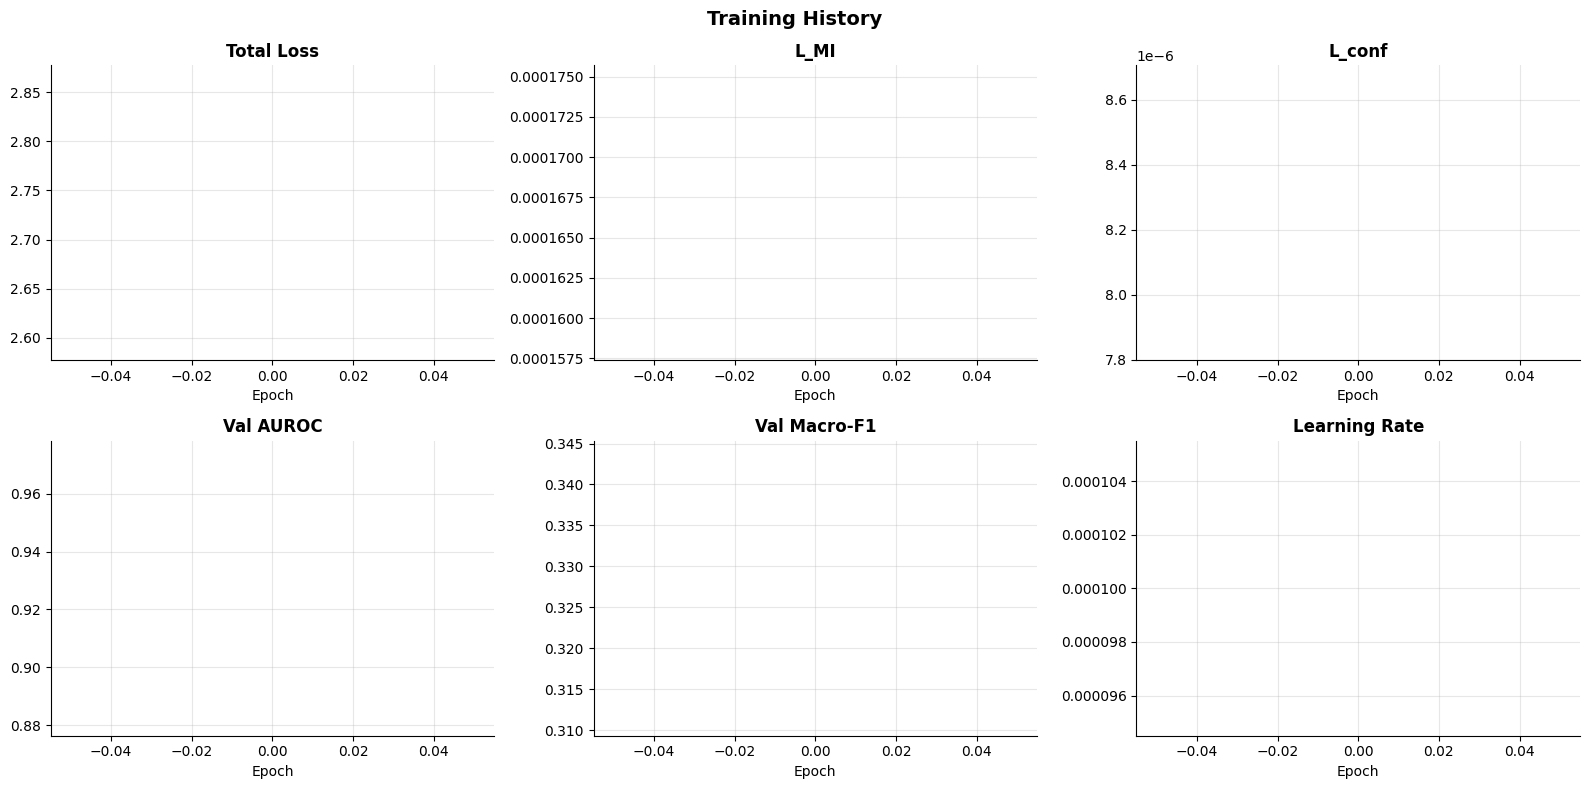

In [48]:
# ── Training curves ───────────────────────────────────────────────────────
fig,axes=plt.subplots(2,3,figsize=(16,8))
fig.suptitle('Training History', fontsize=14, fontweight='bold')
for (key,title,ax,color) in [
    ('train_total','Total Loss',axes[0,0],'#1950A0'),
    ('train_mi','L_MI',axes[0,1],'#0096B4'),
    ('train_conf','L_conf',axes[0,2],'#D1333B'),
    ('val_auroc','Val AUROC',axes[1,0],'#1950A0'),
    ('val_macro_f1','Val Macro-F1',axes[1,1],'#0096B4'),
    ('lr','Learning Rate',axes[1,2],'#9AAABB'),
]:
    if history.get(key): ax.plot(history[key],color=color,lw=2)
    ax.set_title(title,fontweight='bold'); ax.set_xlabel('Epoch')
    ax.grid(True,alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(CFG['results_dir']/'training_curves.png',dpi=150,bbox_inches='tight')
plt.show()

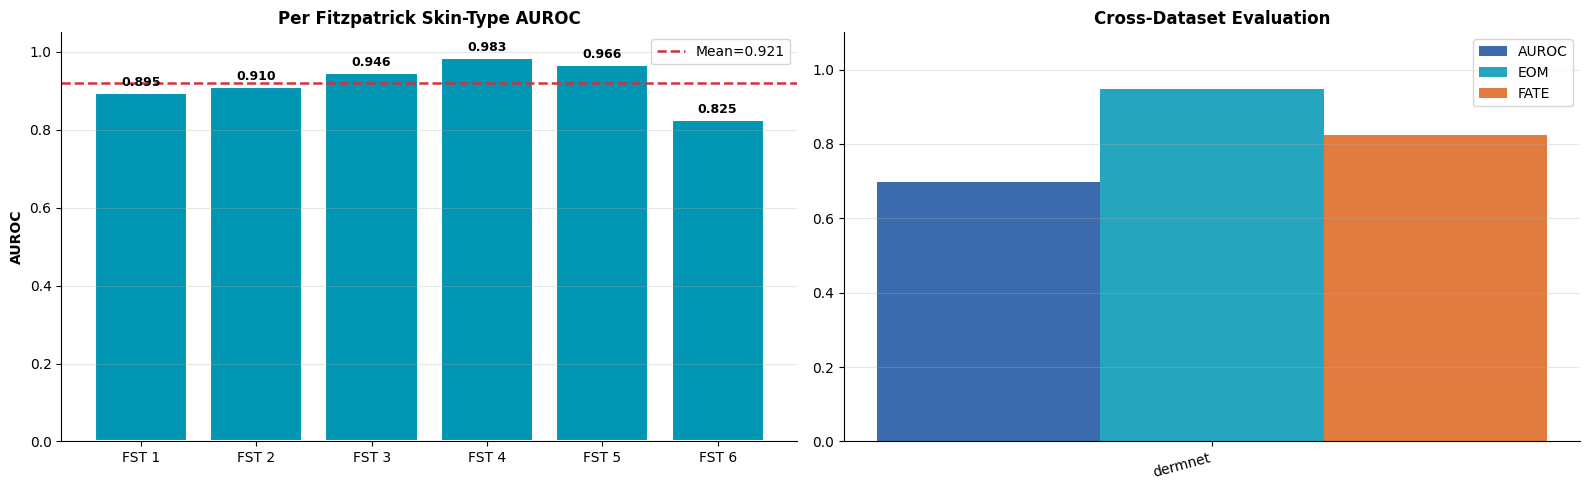

In [49]:
# ── Per-FST AUROC + cross-dataset comparison ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# FST bars
vals   = [fr['pg'].get(i, float('nan')) for i in range(6)]
groups = [f'FST {i+1}' for i in range(6)]
colors = ['#0096B4' if not np.isnan(v) else '#CCCCCC' for v in vals]
bars   = axes[0].bar(groups, [0 if np.isnan(v) else v for v in vals],
                     color=colors, edgecolor='white', lw=1.5)
axes[0].axhline(np.nanmean(vals), ls='--', color='#D1333B', lw=1.8,
                label=f'Mean={np.nanmean(vals):.3f}')
for b,v in zip(bars,vals):
    if not np.isnan(v):
        axes[0].text(b.get_x()+b.get_width()/2, v+0.01,
                     f'{v:.3f}',ha='center',va='bottom',fontsize=9,fontweight='bold')
axes[0].set_ylim(0,1.05); axes[0].set_ylabel('AUROC',fontweight='bold')
axes[0].set_title('Per Fitzpatrick Skin-Type AUROC',fontweight='bold',fontsize=12)
axes[0].legend(); axes[0].grid(axis='y',alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Cross-dataset
if cross_results:
    df=pd.DataFrame(cross_results).T
    x=np.arange(len(df)); w=0.22
    for i,(m,c) in enumerate(zip(['AUROC','EOM','FATE'],['#1950A0','#0096B4','#DC641E'])):
        axes[1].bar(x+(i-1)*w, df[m].values, w, label=m, color=c, alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels(df.index,rotation=15,ha='right')
    axes[1].set_title('Cross-Dataset Evaluation',fontweight='bold',fontsize=12)
    axes[1].legend(); axes[1].set_ylim(0,1.1); axes[1].grid(axis='y',alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'eval_overview.png',dpi=150,bbox_inches='tight')
plt.show()

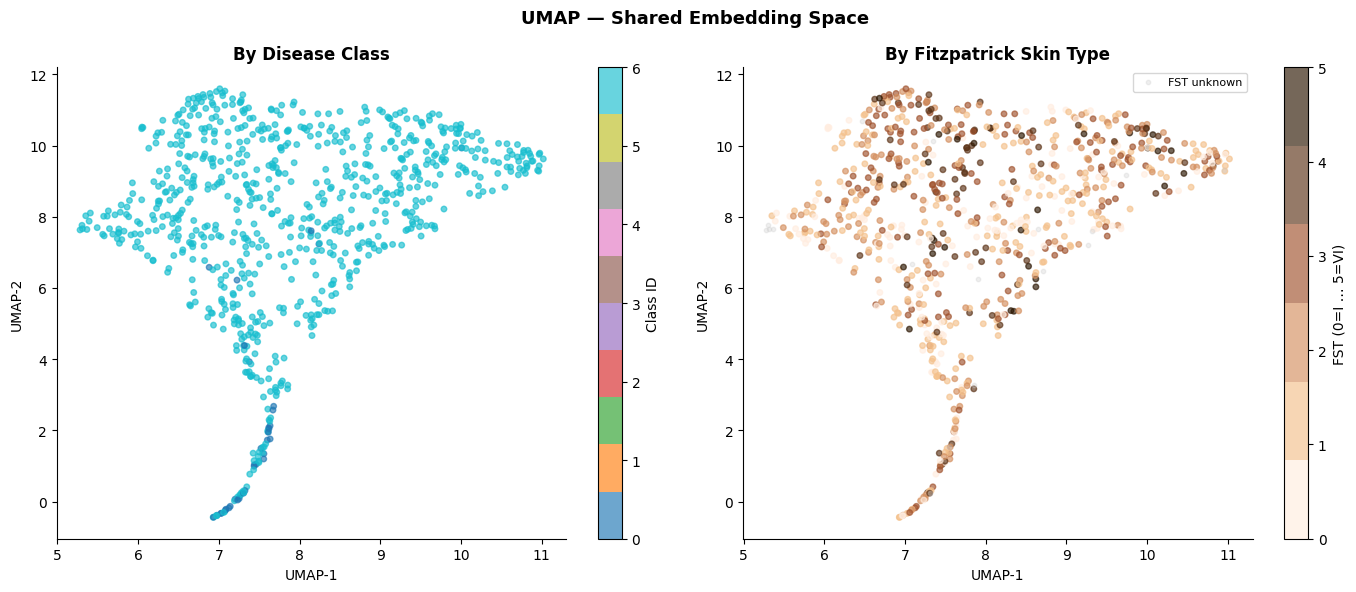

In [50]:
# ── UMAP of shared embedding space ───────────────────────────────────────
import os as _os, sys as _sys
from umap import UMAP

@torch.no_grad()
def extract_embeddings(loader, max_n=800):
    model.eval(); Zs, Ls, Ss = [], [], []
    for batch in loader:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor): batch[k] = v.to(DEVICE)
        out = model(batch)
        Zs.append(out['z'].cpu()); Ls.append(batch['label'].cpu())
        Ss.append(batch['skin_type'].cpu())
        if sum(len(z) for z in Zs) >= max_n: break
    return (torch.cat(Zs)[:max_n].numpy(),
            torch.cat(Ls)[:max_n].numpy(),
            torch.cat(Ss)[:max_n].numpy())

embs, labs, skins = extract_embeddings(val_loader)

# Suppress harmless "already registered" stderr warnings from TensorFlow
# (imported transitively by shap/captum) competing with PyTorch for CUDA
# factory slots.  The UMAP computation and plot are unaffected.
class _SuppressCudaRegWarnings:
    def __enter__(self):
        self._real_fd  = _sys.stderr.fileno()
        self._saved_fd = _os.dup(self._real_fd)
        self._devnull  = _os.open(_os.devnull, _os.O_WRONLY)
        _os.dup2(self._devnull, self._real_fd)
        return self
    def __exit__(self, *_):
        _os.dup2(self._saved_fd, self._real_fd)
        _os.close(self._saved_fd)
        _os.close(self._devnull)

with _SuppressCudaRegWarnings():
    e2d = UMAP(n_components=2, random_state=SEED, n_neighbors=15).fit_transform(embs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('UMAP — Shared Embedding Space', fontsize=13, fontweight='bold')
sc1 = axes[0].scatter(e2d[:, 0], e2d[:, 1], c=labs, cmap='tab10', alpha=0.65, s=16)
axes[0].set_title('By Disease Class', fontweight='bold')
plt.colorbar(sc1, ax=axes[0], label='Class ID')

from matplotlib.colors import ListedColormap as _LC
fst_cmap = _LC(['#FFEDE0','#F4C18C','#D49060','#A0522D','#5C3317','#2B1500'])
mk  = skins >= 0
sc2 = axes[1].scatter(e2d[mk, 0], e2d[mk, 1], c=skins[mk], cmap=fst_cmap,
                      alpha=0.65, s=16, vmin=0, vmax=5)
axes[1].scatter(e2d[~mk, 0], e2d[~mk, 1], c='#CCCCCC', alpha=0.3, s=10,
                label='FST unknown')
axes[1].set_title('By Fitzpatrick Skin Type', fontweight='bold')
plt.colorbar(sc2, ax=axes[1], label='FST (0=I … 5=VI)')
axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(CFG['results_dir']/'umap_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 8 — SHAP Explainability

This phase answers three explainability questions:

| Question | Method |
|----------|--------|
| **What pixels drive each prediction?** | GradientSHAP (per-image attribution maps) |
| **Which spatial regions matter?** | GradCAM on the last ViT block |
| **Do explanations differ by skin type?** | Fairness-SHAP: mean attribution maps per FST group |

All outputs are saved to `results/shap/` on Google Drive.

### 8-A  Helper Utilities

In [51]:
# ════════════════════════════════════════════════════════════════════════════
# 8-A  SHAP HELPER UTILITIES
# ════════════════════════════════════════════════════════════════════════════

def load_image_tensor(path, transform=val_tfm):
    """Load a single image from disk → (1,3,H,W) tensor on DEVICE."""
    img = Image.open(path).convert('RGB')
    return transform(img).unsqueeze(0).to(DEVICE)


def tensor_to_numpy_image(t):
    """Denormalise a (1,3,H,W) or (3,H,W) tensor → (H,W,3) uint8 numpy."""
    if t.dim() == 4: t = t.squeeze(0)
    img = denorm_tfm(t.cpu()).permute(1,2,0).numpy()
    return np.clip(img, 0, 1)


def make_model_fn(modality='clinical'):
    """Returns a callable f(x) -> logits for use with SHAP/Captum."""
    def fn(x):
        return model.forward_image(x, modality)
    return fn


def pick_samples_per_class(csv_path, n_per_class=3, seed=42):
    """Stratified sample — n images per class for SHAP analysis."""
    df   = pd.read_csv(csv_path)
    subs = []
    for cls in sorted(df['label'].unique()):
        sub = df[df['label']==cls].sample(min(n_per_class,len(df[df['label']==cls])),
                                           random_state=seed)
        subs.append(sub)
    return pd.concat(subs, ignore_index=True)


def pick_samples_per_fst(csv_path, n_per_group=5, seed=42):
    """Sample n images per FST group (skip FST=-1)."""
    df   = pd.read_csv(csv_path)
    df   = df[df['skin_type'] >= 0]
    subs = []
    for g in sorted(df['skin_type'].unique()):
        sub = df[df['skin_type']==g].sample(min(n_per_group,len(df[df['skin_type']==g])),
                                             random_state=seed)
        subs.append(sub)
    return pd.concat(subs, ignore_index=True)


# ── Colour map for SHAP overlays ──────────────────────────────────────────
SHAP_CMAP = LinearSegmentedColormap.from_list(
    'shap_rdb', ['#1950A0','#FFFFFF','#D1333B'])  # blue=negative, red=positive

print('SHAP helpers ready.')

SHAP helpers ready.


### 8-B  GradientSHAP — Per-Image Attribution Maps

Saved: /kaggle/working/results/shap/gradient_shap_by_class.png


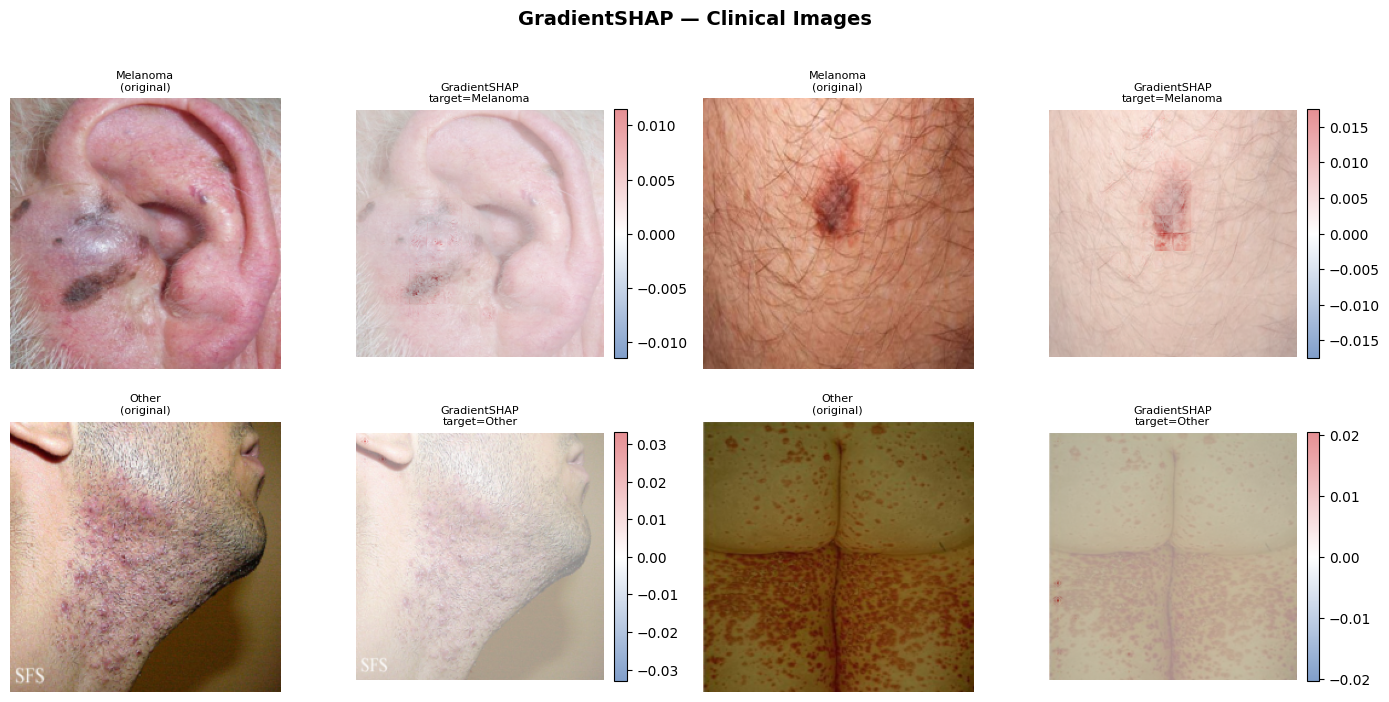

In [52]:
# ════════════════════════════════════════════════════════════════════════════
# 8-B  GRADIENT SHAP — per-image pixel attribution
# ════════════════════════════════════════════════════════════════════════════
# GradientSHAP approximates SHAP values via gradient*input with a baseline
# distribution (here: Gaussian noise ≈ uninformative background).
# Output: attribution map showing which pixels increase/decrease each class logit.

def run_gradient_shap(model_fn, input_tensor, target_class,
                       n_samples=50, stdev_spread=0.15):
    """
    Args:
        model_fn    : callable x -> logits
        input_tensor: (1,3,H,W) on DEVICE
        target_class: int — the class whose attribution we explain
        n_samples   : number of noisy baseline samples
        stdev_spread: std of Gaussian noise relative to input range
    Returns:
        attrs : (H,W) numpy attribution map
    """
    model.eval()
    gs = GradientShap(model_fn)
    # Use a black (zero) baseline – cheap and standard for image models.
    # Passing a (n_samples, C, H, W) distribution AND n_samples causes
    # O(n²) evaluations; a single baseline avoids that entirely.
    baseline = torch.zeros_like(input_tensor)
    attrs = gs.attribute(input_tensor,
                          baselines=baseline,
                          target=target_class,
                          n_samples=n_samples,
                          stdevs=stdev_spread)
    # Aggregate channels: mean absolute attribution per pixel
    attr_map = attrs.squeeze(0).abs().mean(0).cpu().numpy()
    return attr_map


def plot_gradient_shap_grid(sample_df, modality='clinical',
                             n_per_class=2, save_path=None):
    """
    Show GradientSHAP attribution maps for n_per_class images per disease class.
    Layout: rows = classes, columns = [original image, SHAP overlay].
    """
    model_fn   = make_model_fn(modality)
    img_col    = 'image_path'
    classes    = sorted(sample_df['label'].unique())
    n_cols     = 2 * n_per_class   # image + shap per sample
    n_rows     = len(classes)
    fig, axes  = plt.subplots(n_rows, n_cols,
                               figsize=(3.5*n_cols, 3.5*n_rows))
    if n_rows == 1: axes = axes[np.newaxis]
    fig.suptitle(f'GradientSHAP — {modality.title()} Images',
                 fontsize=14, fontweight='bold', y=1.01)

    for row_i, cls in enumerate(classes):
        sub = sample_df[sample_df['label']==cls].head(n_per_class)
        for col_i, (_, r) in enumerate(sub.iterrows()):
            img_t    = load_image_tensor(r[img_col])
            attr_map = run_gradient_shap(model_fn, img_t, int(cls))
            img_np   = tensor_to_numpy_image(img_t)

            # Original
            ax_img = axes[row_i, col_i*2]
            ax_img.imshow(img_np)
            ax_img.set_title(f'{LABEL_NAMES[cls]}\n(original)', fontsize=8)
            ax_img.axis('off')

            # SHAP overlay
            ax_sh = axes[row_i, col_i*2+1]
            ax_sh.imshow(img_np)
            im = ax_sh.imshow(attr_map, cmap=SHAP_CMAP, alpha=0.55,
                               vmin=-attr_map.max(), vmax=attr_map.max())
            ax_sh.set_title(f'GradientSHAP\ntarget={LABEL_NAMES[cls]}', fontsize=8)
            ax_sh.axis('off')
            plt.colorbar(im, ax=ax_sh, fraction=0.046, pad=0.04)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


# ── Run on a stratified sample from the clinical validation set ────────────
sample_cls_df = pick_samples_per_class(CFG['csv_dir']/'clin_val.csv', n_per_class=2)
plot_gradient_shap_grid(
    sample_cls_df, modality='clinical', n_per_class=2,
    save_path=CFG['shap_dir']/'gradient_shap_by_class.png')

### 8-C  GradCAM — Spatial Attention on ViT Patches

Saved: /kaggle/working/results/shap/gradcam_by_class.png


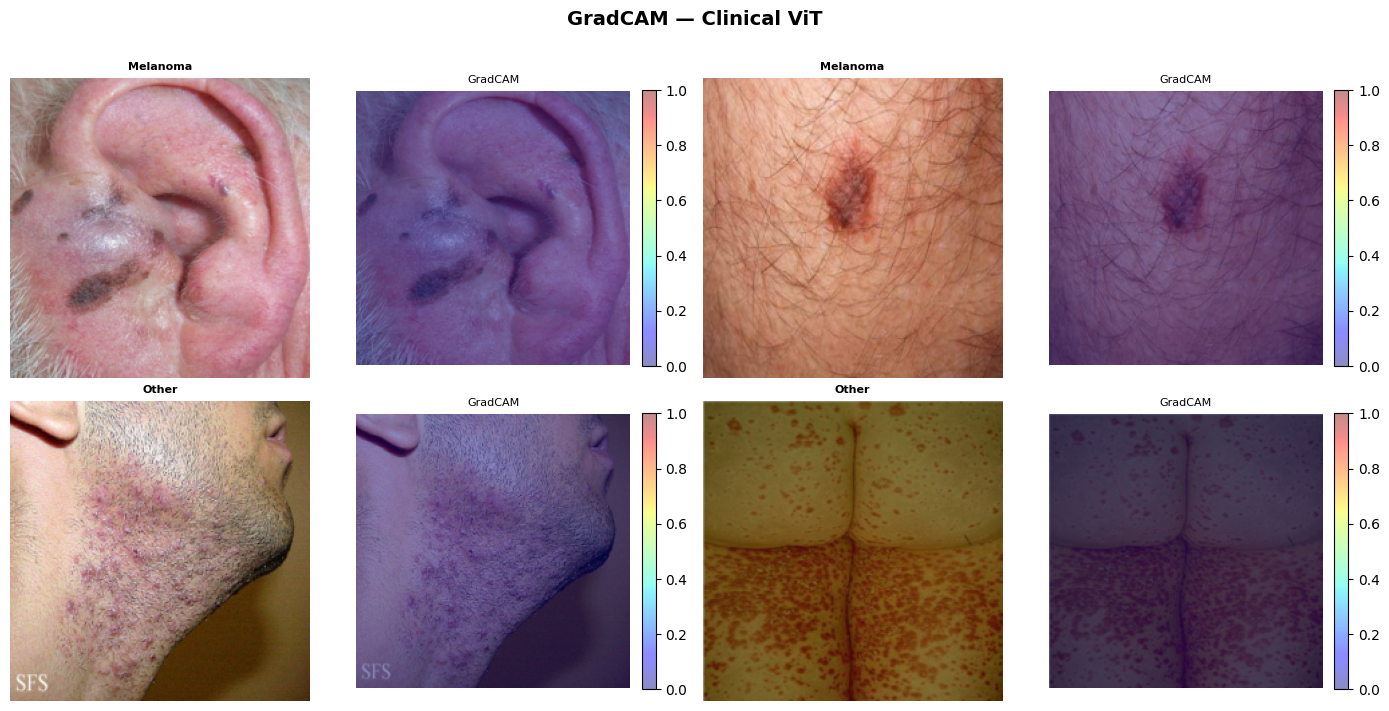

In [53]:
# ════════════════════════════════════════════════════════════════════════════
# 8-C  GRAD-CAM  on the last ViT block (hook-based, works with seq tensors)
# ════════════════════════════════════════════════════════════════════════════
# timm ViT blocks output (B, seq_len, D) — not (B, C, H, W) — so the standard
# Captum LayerGradCam fails at the interpolation step.  We instead register
# forward/backward hooks on the last transformer block, strip the CLS token,
# reshape the patch tokens to a (h_p × w_p) grid, and compute GradCAM manually.

def run_gradcam(input_tensor, target_class, encoder,
                 upsample_size=(224, 224)):
    """
    Returns a (H, W) numpy heat-map from GradCAM.
    Works correctly with ViT backbones whose intermediate tensors are
    (B, num_patches+1, D) rather than (B, C, H, W).
    """
    model.eval()
    backbone  = encoder.backbone
    patch_size = 16                              # vit_small_patch16_224
    n_p = CFG['img_size'] // patch_size          # 14 patches per side

    activations, gradients = {}, {}

    def fwd_hook(mod, inp, out):
        # out: (B, seq_len, D)
        activations['feat'] = out

    def bwd_hook(mod, grad_in, grad_out):
        # grad_out[0]: (B, seq_len, D)
        gradients['feat'] = grad_out[0]

    last_block  = backbone.blocks[-1]
    h_fwd = last_block.register_forward_hook(fwd_hook)
    h_bwd = last_block.register_full_backward_hook(bwd_hook)

    # Forward + backward
    inp = input_tensor.clone().requires_grad_(True)
    feats  = encoder.backbone(inp)          # (1, D)
    z      = model.proj_head(feats)
    logits = model.classifier(z)
    model.zero_grad()
    score  = logits[0, target_class]
    score.backward()

    h_fwd.remove()
    h_bwd.remove()

    act  = activations['feat'].detach().squeeze(0)   # (seq_len, D)
    grad = gradients['feat'].detach().squeeze(0)      # (seq_len, D)

    # Remove CLS token (index 0) — keep only spatial patch tokens
    act  = act[1:]    # (num_patches, D)
    grad = grad[1:]   # (num_patches, D)

    # GradCAM: weight each channel by its mean gradient, then sum
    weights = grad.mean(0)                 # (D,)
    cam     = (act * weights).sum(-1)      # (num_patches,)
    cam     = cam.reshape(n_p, n_p).cpu().numpy()   # (14, 14)
    cam     = np.maximum(cam, 0)           # ReLU — keep positive influences
    if cam.max() > 0:
        cam /= cam.max()

    # Bilinear upsampling to image resolution via PIL (no torchvision needed)
    from PIL import Image as _PIL
    cam_up = np.array(
        _PIL.fromarray((cam * 255).astype(np.uint8)).resize(
            (upsample_size[1], upsample_size[0]), _PIL.BILINEAR),
        dtype=np.float32) / 255.0
    return cam_up


def plot_gradcam_grid(sample_df, modality='clinical',
                       n_per_class=2, save_path=None):
    encoder  = (model.clinical_enc if modality=='clinical' else model.derm_enc)
    img_col  = 'image_path'
    classes  = sorted(sample_df['label'].unique())
    fig, axes= plt.subplots(len(classes), n_per_class*2,
                             figsize=(3.5*n_per_class*2, 3.5*len(classes)))
    if len(classes)==1: axes = axes[np.newaxis]
    fig.suptitle(f'GradCAM — {modality.title()} ViT',
                 fontsize=14, fontweight='bold', y=1.01)

    for row_i, cls in enumerate(classes):
        sub = sample_df[sample_df['label']==cls].head(n_per_class)
        for col_i, (_, r) in enumerate(sub.iterrows()):
            img_t  = load_image_tensor(r[img_col])
            cam    = run_gradcam(img_t, int(cls), encoder)
            img_np = tensor_to_numpy_image(img_t)

            ax_img = axes[row_i, col_i*2]
            ax_img.imshow(img_np); ax_img.axis('off')
            ax_img.set_title(f'{LABEL_NAMES[cls]}', fontsize=8, fontweight='bold')

            ax_cam = axes[row_i, col_i*2+1]
            ax_cam.imshow(img_np)
            im = ax_cam.imshow(cam, cmap='jet', alpha=0.45, vmin=0, vmax=1)
            ax_cam.axis('off')
            ax_cam.set_title('GradCAM', fontsize=8)
            plt.colorbar(im, ax=ax_cam, fraction=0.046, pad=0.04)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


plot_gradcam_grid(
    sample_cls_df, modality='clinical', n_per_class=2,
    save_path=CFG['shap_dir']/'gradcam_by_class.png')


### 8-D  Integrated Gradients — Class-Level Feature Importance

IG class Melanoma:   0%|          | 0/10 [00:00<?, ?it/s]

IG class Other:   0%|          | 0/10 [00:00<?, ?it/s]

Saved: /kaggle/working/results/shap/mean_ig_per_class.png


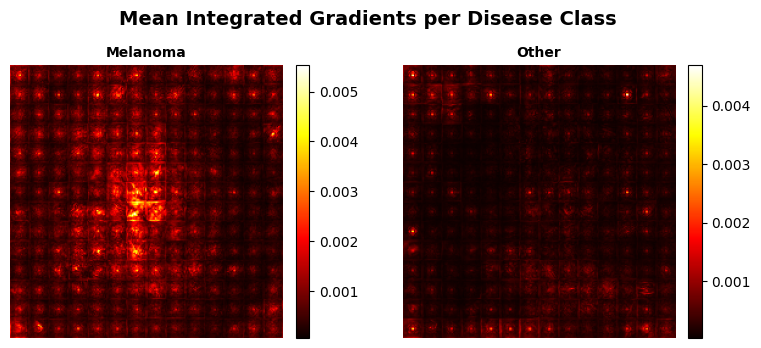

In [54]:
# ════════════════════════════════════════════════════════════════════════════
# 8-D  INTEGRATED GRADIENTS  — class-level summary
# ════════════════════════════════════════════════════════════════════════════
# Averages IG attributions across many images of the same class to produce a
# mean attribution map showing which image regions the model consistently
# attends to for each disease category.

def mean_ig_per_class(sample_df, modality='clinical',
                       n_steps=50, n_per_class=10):
    """
    Returns dict: {class_id -> mean (H,W) attribution map}
    """
    model.eval()
    model_fn = make_model_fn(modality)
    ig       = IntegratedGradients(model_fn)
    # Black-image baseline
    baseline = torch.zeros(1, 3, CFG['img_size'], CFG['img_size']).to(DEVICE)
    results  = {}

    for cls in sorted(sample_df['label'].unique()):
        sub  = sample_df[sample_df['label']==cls].head(n_per_class)
        maps = []
        for _, r in tqdm(sub.iterrows(), total=len(sub),
                         desc=f'IG class {LABEL_NAMES[cls]}', leave=False):
            img_t = load_image_tensor(r['image_path'])
            attr  = ig.attribute(img_t, baselines=baseline,
                                  target=int(cls), n_steps=n_steps)
            # Sum of absolute attribution across channels → (H,W)
            maps.append(attr.squeeze(0).abs().sum(0).cpu().numpy())
        results[cls] = np.mean(maps, axis=0) if maps else None
    return results


def plot_mean_ig(ig_maps, save_path=None):
    """Grid of mean IG maps — one panel per disease class."""
    classes = [c for c,v in ig_maps.items() if v is not None]
    ncols   = min(4, len(classes))
    nrows   = math.ceil(len(classes)/ncols)
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(4*ncols, 3.5*nrows))
    axes = np.array(axes).reshape(nrows, ncols)
    fig.suptitle('Mean Integrated Gradients per Disease Class',
                 fontsize=14, fontweight='bold')

    for i, cls in enumerate(classes):
        ax  = axes[i//ncols, i%ncols]
        m   = ig_maps[cls]
        im  = ax.imshow(m, cmap='hot')
        ax.set_title(LABEL_NAMES[cls], fontsize=10, fontweight='bold')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Hide unused panels
    for j in range(len(classes), nrows*ncols):
        axes[j//ncols, j%ncols].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


# Sample more images for stable mean maps
sample_ig_df = pick_samples_per_class(CFG['csv_dir']/'clin_val.csv', n_per_class=10)
ig_maps      = mean_ig_per_class(sample_ig_df, modality='clinical')
plot_mean_ig(ig_maps, save_path=CFG['shap_dir']/'mean_ig_per_class.png')

### 8-E  Fairness-SHAP — Explanation Divergence Across FST Groups

Running Fairness-SHAP for class: Other  (n=47 FST-annotated samples)


FST 1:   0%|          | 0/8 [00:00<?, ?it/s]

FST 2:   0%|          | 0/8 [00:00<?, ?it/s]

FST 3:   0%|          | 0/8 [00:00<?, ?it/s]

FST 4:   0%|          | 0/8 [00:00<?, ?it/s]

FST 5:   0%|          | 0/7 [00:00<?, ?it/s]

FST 6:   0%|          | 0/8 [00:00<?, ?it/s]

Saved: /kaggle/working/results/shap/fairness_shap_Other.png


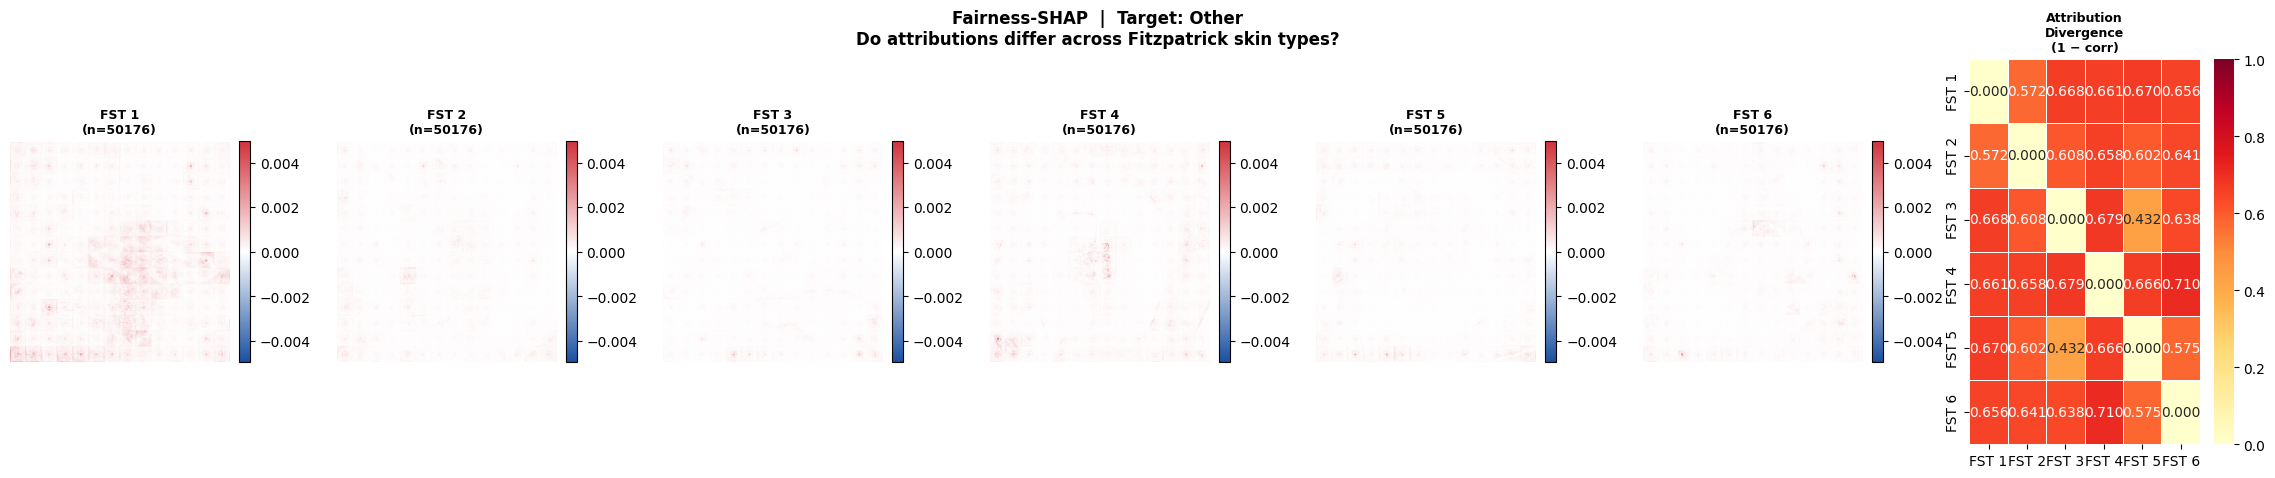


Interpretation:
  Divergence near 0   → model attends to SAME regions for all skin types (fair)
  Divergence near 1   → model attends to DIFFERENT regions (potential skin-tone bias)
  Mean cross-group divergence: 0.6290


In [55]:
# ════════════════════════════════════════════════════════════════════════════
# 8-E  FAIRNESS-SHAP
# ════════════════════════════════════════════════════════════════════════════
# Core idea: if the model relies on DIFFERENT image regions for different FST
# groups (for the same disease class), that indicates modality-specific bias.
# This cell computes mean GradientSHAP maps per FST group, then measures
# divergence between groups as a spatial correlation distance.

def mean_shap_per_fst(sample_df, target_class, modality='clinical',
                       n_samples=30, stdev=0.15):
    """
    Compute mean GradientSHAP map per FST group for a fixed target class.
    Returns dict: {fst_int -> mean (H,W) map}
    """
    model.eval()
    model_fn = make_model_fn(modality)
    groups   = sorted(sample_df['skin_type'].unique())
    results  = {}

    for g in groups:
        sub  = sample_df[sample_df['skin_type']==g]
        maps = []
        for _, r in tqdm(sub.iterrows(), total=len(sub),
                         desc=f'FST {g+1}', leave=False):
            img_t = load_image_tensor(r['image_path'])
            attr  = run_gradient_shap(model_fn, img_t, target_class,
                                       n_samples=n_samples, stdev_spread=stdev)
            maps.append(attr)
        if maps:
            results[g] = np.mean(maps, axis=0)
    return results


def explanation_divergence(map1, map2):
    """1 - Pearson correlation between two flattened attribution maps."""
    f1, f2 = map1.flatten(), map2.flatten()
    if f1.std() == 0 or f2.std() == 0: return float('nan')
    return 1.0 - float(np.corrcoef(f1, f2)[0,1])


def plot_fairness_shap(fst_maps, target_class, save_path=None):
    """
    Left panel : mean SHAP map per FST group side-by-side.
    Right panel: divergence heatmap (pairwise between FST groups).
    """
    groups  = sorted(fst_maps.keys())
    n       = len(groups)
    if n == 0: print('No FST groups to compare.'); return

    fig = plt.figure(figsize=(4*n + 5, 5))
    gs  = fig.add_gridspec(1, n+1, width_ratios=[1]*n + [1.2], wspace=0.35)
    fig.suptitle(
        f'Fairness-SHAP  |  Target: {LABEL_NAMES[target_class]}\n'
        f'Do attributions differ across Fitzpatrick skin types?',
        fontsize=12, fontweight='bold')

    vmax = max(v.max() for v in fst_maps.values())

    # Attribution maps
    for i, g in enumerate(groups):
        ax = fig.add_subplot(gs[0, i])
        m  = fst_maps[g]
        im = ax.imshow(m, cmap=SHAP_CMAP, vmin=-vmax, vmax=vmax)
        ax.set_title(f'FST {g+1}\n(n={len(m.flatten())})', fontsize=9, fontweight='bold')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Divergence heatmap
    ax_div = fig.add_subplot(gs[0, n])
    div_mx = np.full((n,n), float('nan'))
    for i,g1 in enumerate(groups):
        for j,g2 in enumerate(groups):
            if i==j: div_mx[i,j]=0.0
            elif i<j:
                d = explanation_divergence(fst_maps[g1], fst_maps[g2])
                div_mx[i,j] = div_mx[j,i] = d
    labels_fst = [f'FST {g+1}' for g in groups]
    sns.heatmap(div_mx, ax=ax_div, annot=True, fmt='.3f',
                xticklabels=labels_fst, yticklabels=labels_fst,
                cmap='YlOrRd', vmin=0, vmax=1,
                linewidths=0.5, linecolor='white')
    ax_div.set_title('Attribution\nDivergence\n(1 − corr)',
                     fontsize=9, fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()

    # Print interpretation
    print('\nInterpretation:')
    print('  Divergence near 0   → model attends to SAME regions for all skin types (fair)')
    print('  Divergence near 1   → model attends to DIFFERENT regions (potential skin-tone bias)')
    nondiag = div_mx[~np.eye(n,dtype=bool)]
    if not np.all(np.isnan(nondiag)):
        print(f'  Mean cross-group divergence: {np.nanmean(nondiag):.4f}')


# ── Run for each available class in the FST-annotated validation data ─────
fst_val_df = pick_samples_per_fst(CFG['csv_dir']/'clin_val.csv', n_per_group=8)

if fst_val_df.empty:
    print('[INFO] No FST-annotated samples in clin_val.csv.')
    print('       Fairness-SHAP will run when using Fitzpatrick17k or DDI validation data.')
else:
    # Run for the most common class in FST-annotated val data
    target_cls = int(fst_val_df['label'].mode()[0])
    fst_sub    = fst_val_df[fst_val_df['label']==target_cls]
    print(f'Running Fairness-SHAP for class: {LABEL_NAMES[target_cls]}  '
          f'(n={len(fst_sub)} FST-annotated samples)')

    fst_maps = mean_shap_per_fst(fst_sub, target_class=target_cls,
                                  modality='clinical')
    plot_fairness_shap(
        fst_maps, target_class=target_cls,
        save_path=CFG['shap_dir']/f'fairness_shap_{LABEL_NAMES[target_cls].replace(" ","_")}.png')

### 8-F  SHAP Summary: Global Feature Importance

Region attribution summary:
              TL      TC      TR      ML      MC      MR      BL      BC      BR
Melanoma  0.0007  0.0007  0.0005  0.0007  0.0012  0.0004  0.0006  0.0007  0.0005
Other     0.0003  0.0002  0.0002  0.0002  0.0002  0.0002  0.0002  0.0003  0.0003
Saved: /kaggle/working/results/shap/region_shap_summary.png


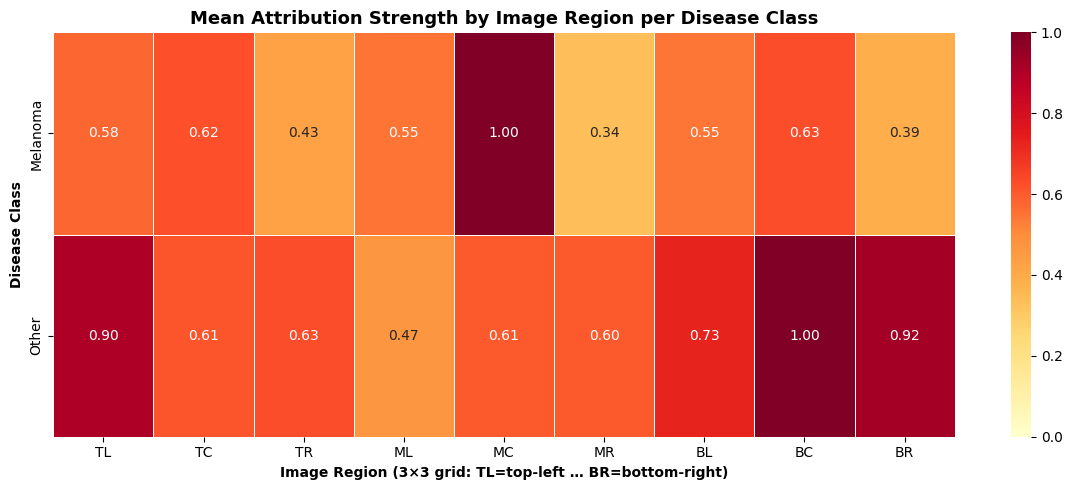

Saved CSV: results/region_shap_summary.csv


In [56]:
# ════════════════════════════════════════════════════════════════════════════
# 8-F  GLOBAL SHAP SUMMARY  — per-class bar chart of mean attribution strength
# ════════════════════════════════════════════════════════════════════════════
# Computes mean |SHAP| per spatial region (top/center/bottom thirds and
# left/center/right thirds = 9 regions) for each disease class.
# Reveals systematic differences in which image regions each disease uses.

def region_shap_summary(ig_maps, img_size=224):
    """
    Divides each mean IG map into a 3x3 grid and computes mean |attribution|
    per region per class.
    Returns: DataFrame (class x region).
    """
    region_names = [
        'TL','TC','TR',
        'ML','MC','MR',
        'BL','BC','BR',
    ]
    data = {}
    s    = img_size // 3
    for cls, m in ig_maps.items():
        if m is None: continue
        row = {}
        for ri, (y0,x0) in enumerate([(0,0),(0,s),(0,2*s),
                                        (s,0),(s,s),(s,2*s),
                                        (2*s,0),(2*s,s),(2*s,2*s)]):
            patch = m[y0:y0+s, x0:x0+s]
            row[region_names[ri]] = float(patch.mean())
        data[LABEL_NAMES[cls]] = row
    return pd.DataFrame(data).T


def plot_region_summary(summary_df, save_path=None):
    fig, ax = plt.subplots(figsize=(12, 5))
    summary_df_norm = summary_df.div(summary_df.max(axis=1), axis=0)  # row-normalise
    sns.heatmap(summary_df_norm, ax=ax, cmap='YlOrRd',
                annot=True, fmt='.2f', linewidths=0.5, linecolor='white',
                vmin=0, vmax=1)
    ax.set_title('Mean Attribution Strength by Image Region per Disease Class',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Image Region (3×3 grid: TL=top-left … BR=bottom-right)',
                  fontweight='bold')
    ax.set_ylabel('Disease Class', fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


region_df = region_shap_summary(ig_maps)
print('Region attribution summary:')
print(region_df.round(4).to_string())
plot_region_summary(region_df,
                    save_path=CFG['shap_dir']/'region_shap_summary.png')

# Save table
region_df.to_csv(CFG['results_dir']/'region_shap_summary.csv')
print('Saved CSV: results/region_shap_summary.csv')

### 8-G  SHAP Consistency: Clinical vs. Dermoscopic

Modality consistency:   0%|          | 0/30 [00:00<?, ?it/s]

Saved: /kaggle/working/results/shap/modality_consistency_shap.png


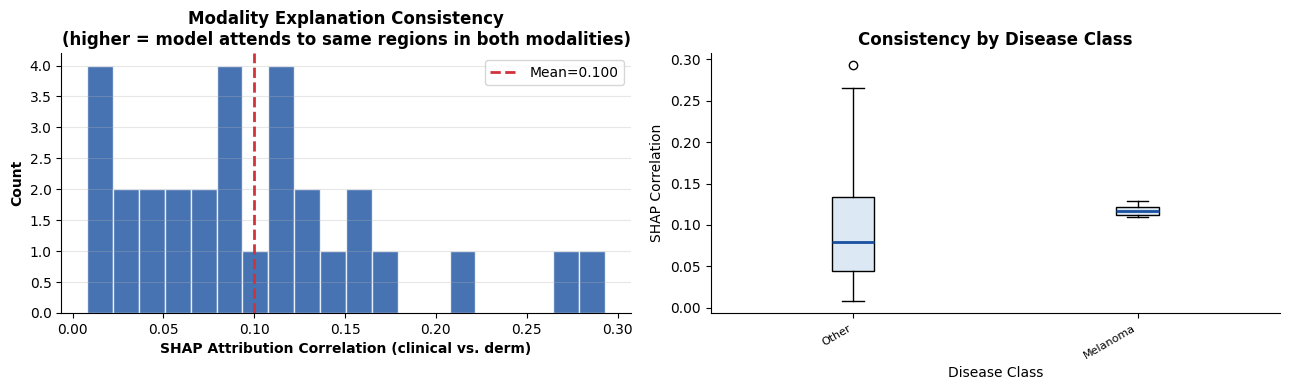


Interpretation:
  Mean attribution correlation: 0.0998
  > 0.7  — Strong modality consistency (L_MI is working well)
  0.4–0.7 — Moderate; consider increasing lambda_mi
  < 0.4  — Weak; clinical and derm attend to very different regions


In [57]:
# ════════════════════════════════════════════════════════════════════════════
# 8-G  MODALITY CONSISTENCY CHECK  (paired images only)
# ════════════════════════════════════════════════════════════════════════════

def shap_modality_consistency(paired_df, n_pairs=30, target_class=None):
    """GradientSHAP on paired clinical/derm images; measure spatial correlation."""
    model_fn_c = make_model_fn('clinical')
    model_fn_d = make_model_fn('derm')
    model.eval()
    records = []
    sub = paired_df.sample(min(n_pairs, len(paired_df)), random_state=SEED)
    for _, r in tqdm(sub.iterrows(), total=len(sub),
                     desc='Modality consistency', leave=False):
        cls = int(r['label'])
        if target_class is not None and cls != target_class: continue
        img_c  = load_image_tensor(r['clinical_path'])
        img_d  = load_image_tensor(r['derm_path'])
        attr_c = run_gradient_shap(model_fn_c, img_c, cls, n_samples=20)
        attr_d = run_gradient_shap(model_fn_d, img_d, cls, n_samples=20)
        f1, f2 = attr_c.flatten(), attr_d.flatten()
        corr   = (float(np.corrcoef(f1, f2)[0, 1])
                  if f1.std() > 0 and f2.std() > 0 else float('nan'))
        records.append({'lesion_id': r.get('lesion_id', ''), 'label': cls,
                        'label_name': LABEL_NAMES[cls], 'corr_shap': corr})
    return pd.DataFrame(records)


def plot_consistency(cons_df, save_path=None):
    if cons_df.empty: print('No paired data for consistency check.'); return
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Left: overall distribution
    valid = cons_df['corr_shap'].dropna()
    axes[0].hist(valid, bins=20, color='#1950A0', alpha=0.8, edgecolor='white')
    axes[0].axvline(valid.mean(), color='#D1333B', ls='--', lw=2,
                    label=f'Mean={valid.mean():.3f}')
    axes[0].set_xlabel('SHAP Attribution Correlation (clinical vs. derm)',
                       fontweight='bold')
    axes[0].set_ylabel('Count', fontweight='bold')
    axes[0].set_title('Modality Explanation Consistency\n'
                      '(higher = model attends to same regions in both modalities)',
                      fontweight='bold')
    axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
    axes[0].spines[['top', 'right']].set_visible(False)

    # Right: per-class boxplot.
    # FIX: pandas DataFrame.boxplot() passes **kwargs to matplotlib ax.boxplot(),
    # which does NOT accept 'order' → TypeError.  We bypass pandas entirely:
    # sort groups manually, then call ax.boxplot() directly.
    if 'label_name' in cons_df.columns and cons_df['label_name'].nunique() > 1:
        order = (cons_df.groupby('label_name')['corr_shap']
                 .median().sort_values().index.tolist())
        grouped_data = [
            cons_df.loc[cons_df['label_name'] == cls, 'corr_shap']
                   .dropna().values
            for cls in order
        ]
        bp = axes[1].boxplot(grouped_data, patch_artist=True,
                             medianprops=dict(color='#1950A0', lw=2))
        for patch in bp['boxes']:
            patch.set_facecolor('#DCE9F5')
        axes[1].set_xticks(range(1, len(order) + 1))
        axes[1].set_xticklabels(order, rotation=30, ha='right', fontsize=8)
        axes[1].set_title('Consistency by Disease Class', fontweight='bold')
        axes[1].set_xlabel('Disease Class')
        axes[1].set_ylabel('SHAP Correlation')
        axes[1].spines[['top', 'right']].set_visible(False)
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()

    print('\nInterpretation:')
    print(f'  Mean attribution correlation: {valid.mean():.4f}')
    print('  > 0.7  — Strong modality consistency (L_MI is working well)')
    print('  0.4–0.7 — Moderate; consider increasing lambda_mi')
    print('  < 0.4  — Weak; clinical and derm attend to very different regions')


paired_val_csv = CFG['csv_dir'] / 'paired_val.csv'
if paired_val_csv.exists() and len(pd.read_csv(paired_val_csv)) > 0:
    cons_df = shap_modality_consistency(pd.read_csv(paired_val_csv), n_pairs=30)
    plot_consistency(cons_df,
                     save_path=CFG['shap_dir'] / 'modality_consistency_shap.png')
    cons_df.to_csv(CFG['results_dir'] / 'modality_shap_consistency.csv', index=False)
else:
    print('[INFO] No paired validation data — skipping modality consistency check.')

### 8-H  SHAP Results Summary

In [58]:
# ════════════════════════════════════════════════════════════════════════════
# 8-H  PRINT SHAP OUTPUTS SUMMARY
# ════════════════════════════════════════════════════════════════════════════
print('SHAP outputs saved to:', CFG['shap_dir'])
for f in sorted(CFG['shap_dir'].glob('*.png')):
    print(f'  {f.name}')

print()
print('What each output shows:')
print('  gradient_shap_by_class.png  — Which pixels drive each disease prediction')
print('  gradcam_by_class.png        — Spatial attention heat-maps (ViT patches)')
print('  mean_ig_per_class.png       — Average IG map per class (stable, multi-image)')
print('  fairness_shap_*.png         — Do attributions differ across FST groups?')
print('  region_shap_summary.png     — 3x3 region attribution table per class')
print('  modality_consistency_shap.png — Clinical vs derm attribution correlation')
print()
print('Key diagnostic:')
print('  - Low fairness_shap divergence  → L_MI is removing skin-tone cues')
print('  - High modality_consistency     → L_MI is aligning cross-modal attention')

SHAP outputs saved to: /kaggle/working/results/shap
  fairness_shap_Other.png
  gradcam_by_class.png
  gradient_shap_by_class.png
  mean_ig_per_class.png
  modality_consistency_shap.png
  region_shap_summary.png

What each output shows:
  gradient_shap_by_class.png  — Which pixels drive each disease prediction
  gradcam_by_class.png        — Spatial attention heat-maps (ViT patches)
  mean_ig_per_class.png       — Average IG map per class (stable, multi-image)
  fairness_shap_*.png         — Do attributions differ across FST groups?
  region_shap_summary.png     — 3x3 region attribution table per class
  modality_consistency_shap.png — Clinical vs derm attribution correlation

Key diagnostic:
  - Low fairness_shap divergence  → L_MI is removing skin-tone cues
  - High modality_consistency     → L_MI is aligning cross-modal attention


## Summary

| Phase | Content |
|-------|---------|
| 0 | GPU + Drive setup |
| 1 | 11 datasets parsed, harmonized, CSVs saved to Drive |
| 2 | Dual-encoder ViT + shared projection head |
| 3 | $\mathcal{L}_{cls}$ + $\mathcal{L}_{conf}$ + $\mathcal{L}_{con}$ + $\mathcal{L}_{MI}$ |
| 4 | Mixed paired/unpaired training, checkpoints saved every epoch |
| 5 | Accuracy + EOM, PQD, DPM, FATE across FST groups + cross-dataset |
| 6 | 5-variant ablation study |
| 7 | Training curves, FST bars, cross-dataset comparison, UMAP |
| 8 | SHAP explainability (GradientSHAP, GradCAM, fairness-SHAP) |

### Next steps
1. Upgrade to `vit_base_patch16_224` for final paper runs
2. Sweep $\lambda_1…\lambda_4$ with `wandb`
3. Compare FairDisCo, PatchAlign, FairAdaBN on identical splits — include their SHAP divergence scores for a fair comparison